# Vietnamese Hate Speech Detection - ViHSD
## Nhan dien ngon tu thu ghet tieng Viet
[Paper A Large-scale Dataset for Hate Speech
Detection on Vietnamese Social Media Texts](https://arxiv.org/pdf/2103.11528#page=1.32)


## Cai dat thu vien & Cau hinh

In [1]:
!pip install datasets underthesea pyvi wordcloud lime lightgbm catboost optuna -q
!pip install imbalanced-learn -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import re, string, unicodedata, os, json, time
from collections import Counter
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from underthesea import word_tokenize as vn_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack, csr_matrix
from lime.lime_text import LimeTextExplainer
import joblib

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
SEED = 42
np.random.seed(SEED)

LABEL_NAMES  = ['CLEAN', 'OFFENSIVE', 'HATE']
LABEL_COLORS = {'CLEAN': '#2ecc71', 'OFFENSIVE': '#f39c12', 'HATE': '#e74c3c'}
LABEL_MAP    = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}

print(f"OK Import hoan tat | numpy {np.__version__} | pandas {pd.__version__}")


OK Import hoan tat | numpy 2.0.2 | pandas 2.2.2


## Load Dataset ViHSD
Load truc tiep tu HuggingFace Hub - `uitnlp/vihsd`.

In [3]:
from huggingface_hub import login
login(token="YOUR_HF_TOKEN")

In [4]:
print("Dang tai dataset uitnlp/vihsd ...")
dataset = load_dataset("uitnlp/vihsd")

df_train = dataset['train'].to_pandas()
df_val   = dataset['validation'].to_pandas()
df_test  = dataset['test'].to_pandas()

for df in [df_train, df_val, df_test]:
    df.rename(columns={'free_label': 'label'}, inplace=True, errors='ignore')
    if 'label_id' in df.columns:
        df.rename(columns={'label_id': 'label'}, inplace=True)
    df['label_name'] = df['label'].map(LABEL_MAP)

print(f"OK Load thanh cong!")
print(f"   Train : {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
print(f"   Total : {len(df_train)+len(df_val)+len(df_test):,} samples")
df_train.head(10)


Dang tai dataset uitnlp/vihsd ...


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

dev.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/24048 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6680 [00:00<?, ? examples/s]

OK Load thanh cong!
   Train : 24,048 | Val: 2,672 | Test: 6,680
   Total : 33,400 samples


,free_text,label,label_name
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0,CLEAN
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2,HATE
2,Đậu Văn Cường giờ giống thằng sida hơn à,0,CLEAN
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2,HATE
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0,CLEAN
5,Coronavirus is manmade,0,CLEAN
6,Đố chúng m nhận ra ai,0,CLEAN
7,Lúp lúp như chó .,1,OFFENSIVE
8,🥰🥰🥰,0,CLEAN
9,"Thế mà mình nói mấy thằng bắc kì, bọn đó lại b...",2,HATE


In [5]:
print("Columns:", df_train.columns.tolist())
print("Dtypes:", df_train.dtypes.to_string())
print("\nPhan bo nhan train:")
print(df_train['label_name'].value_counts())


Columns: ['free_text', 'label', 'label_name']
Dtypes: free_text     object
label          int64
label_name    object

Phan bo nhan train:
label_name
CLEAN        19886
HATE          2556
OFFENSIVE     1606
Name: count, dtype: int64



## EDA

### 1 - Thong ke tong quan & Phan bo nhan

In [6]:
total = len(df_train) + len(df_val) + len(df_test)
print("  TONG QUAN DATASET ViHSD")
for split_name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    print(f"\n  [{split_name}] - {len(df):,} samples")
    for lbl in LABEL_NAMES:
        n = (df['label_name'] == lbl).sum()
        pct = n / len(df) * 100
        bar = 'X' * int(pct / 2)
        print(f"    {lbl:10s}: {n:5,} ({pct:5.1f}%)  {bar}")
print(f"\n  Tong cong: {total:,} samples")


  TONG QUAN DATASET ViHSD

  [Train] - 24,048 samples
    CLEAN     : 19,886 ( 82.7%)  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
    OFFENSIVE : 1,606 (  6.7%)  XXX
    HATE      : 2,556 ( 10.6%)  XXXXX

  [Val] - 2,672 samples
    CLEAN     : 2,190 ( 82.0%)  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
    OFFENSIVE :   212 (  7.9%)  XXX
    HATE      :   270 ( 10.1%)  XXXXX

  [Test] - 6,680 samples
    CLEAN     : 5,548 ( 83.1%)  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
    OFFENSIVE :   444 (  6.6%)  XXX
    HATE      :   688 ( 10.3%)  XXXXX

  Tong cong: 33,400 samples


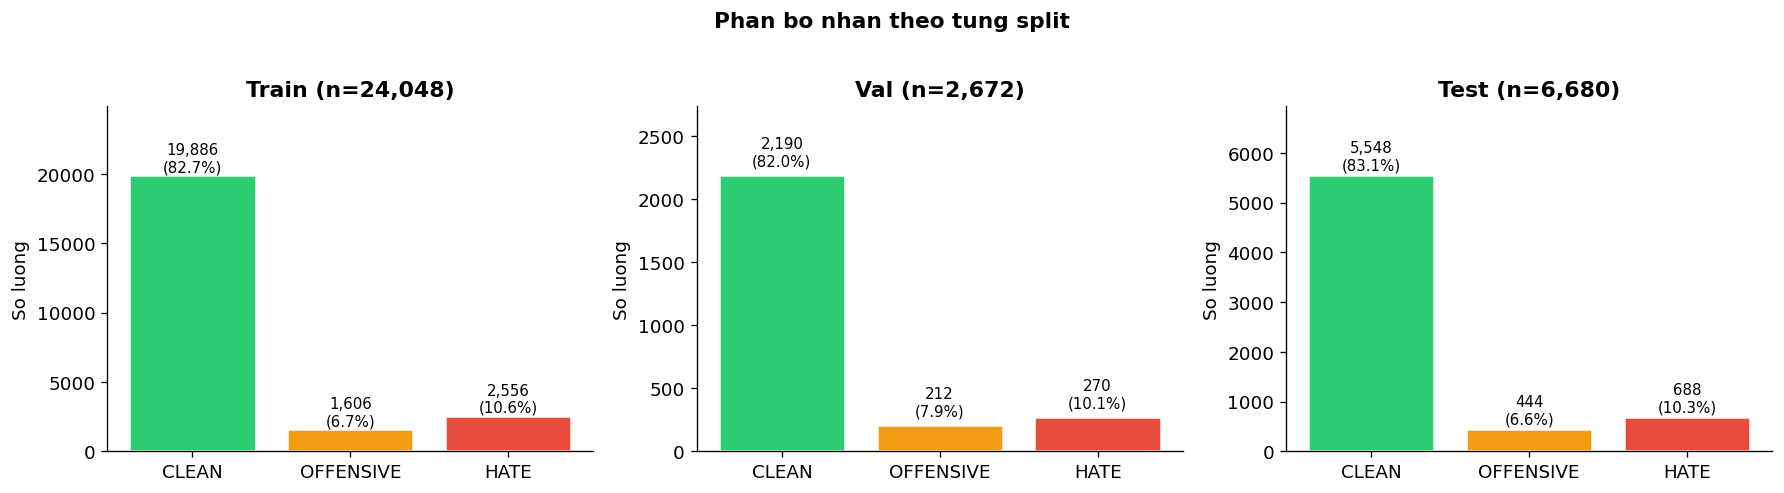


CANH BAO: Dataset mat can bang nghiem trong!
   CLEAN     : 82.7%
   OFFENSIVE : 6.7%
   HATE      : 10.6%
   -> Can xu ly class imbalance trong Phase 3


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phan bo nhan theo tung split', fontsize=13, fontweight='bold', y=1.02)

for ax, (split_name, df) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = df['label_name'].value_counts().reindex(LABEL_NAMES)
    colors = [LABEL_COLORS[l] for l in LABEL_NAMES]
    bars = ax.bar(LABEL_NAMES, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{split_name} (n={len(df):,})', fontweight='bold')
    ax.set_ylabel('So luong')
    ax.set_ylim(0, counts.max() * 1.25)

plt.tight_layout()
plt.savefig('2A_label_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

print("\nCANH BAO: Dataset mat can bang nghiem trong!")
for lbl in LABEL_NAMES:
    print(f"   {lbl:10s}: {(df_train['label_name']==lbl).mean()*100:.1f}%")
print("   -> Can xu ly class imbalance trong Phase 3")



### 2 - Phan tich Do dai Van ban

In [8]:
TEXT_COL = [c for c in df_train.columns if c not in ['label','label_name']][0]
print(f"Text column: '{TEXT_COL}'")

for df in [df_train, df_val, df_test]:
    df['text'] = df[TEXT_COL].astype(str)
    df['char_len'] = df['text'].apply(len)
    df['word_len'] = df['text'].apply(lambda x: len(x.split()))

print("\nThong ke do dai (ky tu) theo nhan - Train set:")
stats = df_train.groupby('label_name')['char_len'].describe()[['min','mean','50%','max','std']]
stats.columns = ['Min','Mean','Median','Max','Std']
print(stats.round(1).to_string())

print("\nThong ke do dai (tu) theo nhan - Train set:")
stats_w = df_train.groupby('label_name')['word_len'].describe()[['min','mean','50%','max','std']]
stats_w.columns = ['Min','Mean','Median','Max','Std']
print(stats_w.round(1).to_string())


Text column: 'free_text'

Thong ke do dai (ky tu) theo nhan - Train set:
            Min  Mean  Median      Max    Std
label_name                                   
CLEAN       1.0  45.3    32.0  20816.0  200.6
HATE        4.0  83.8    59.0    707.0   74.7
OFFENSIVE   2.0  44.1    31.0    385.0   46.0

Thong ke do dai (tu) theo nhan - Train set:
            Min  Mean  Median     Max   Std
label_name                                 
CLEAN       1.0  10.5     8.0  1701.0  20.6
HATE        1.0  20.0    14.0   162.0  17.5
OFFENSIVE   1.0  10.7     8.0    97.0  10.7


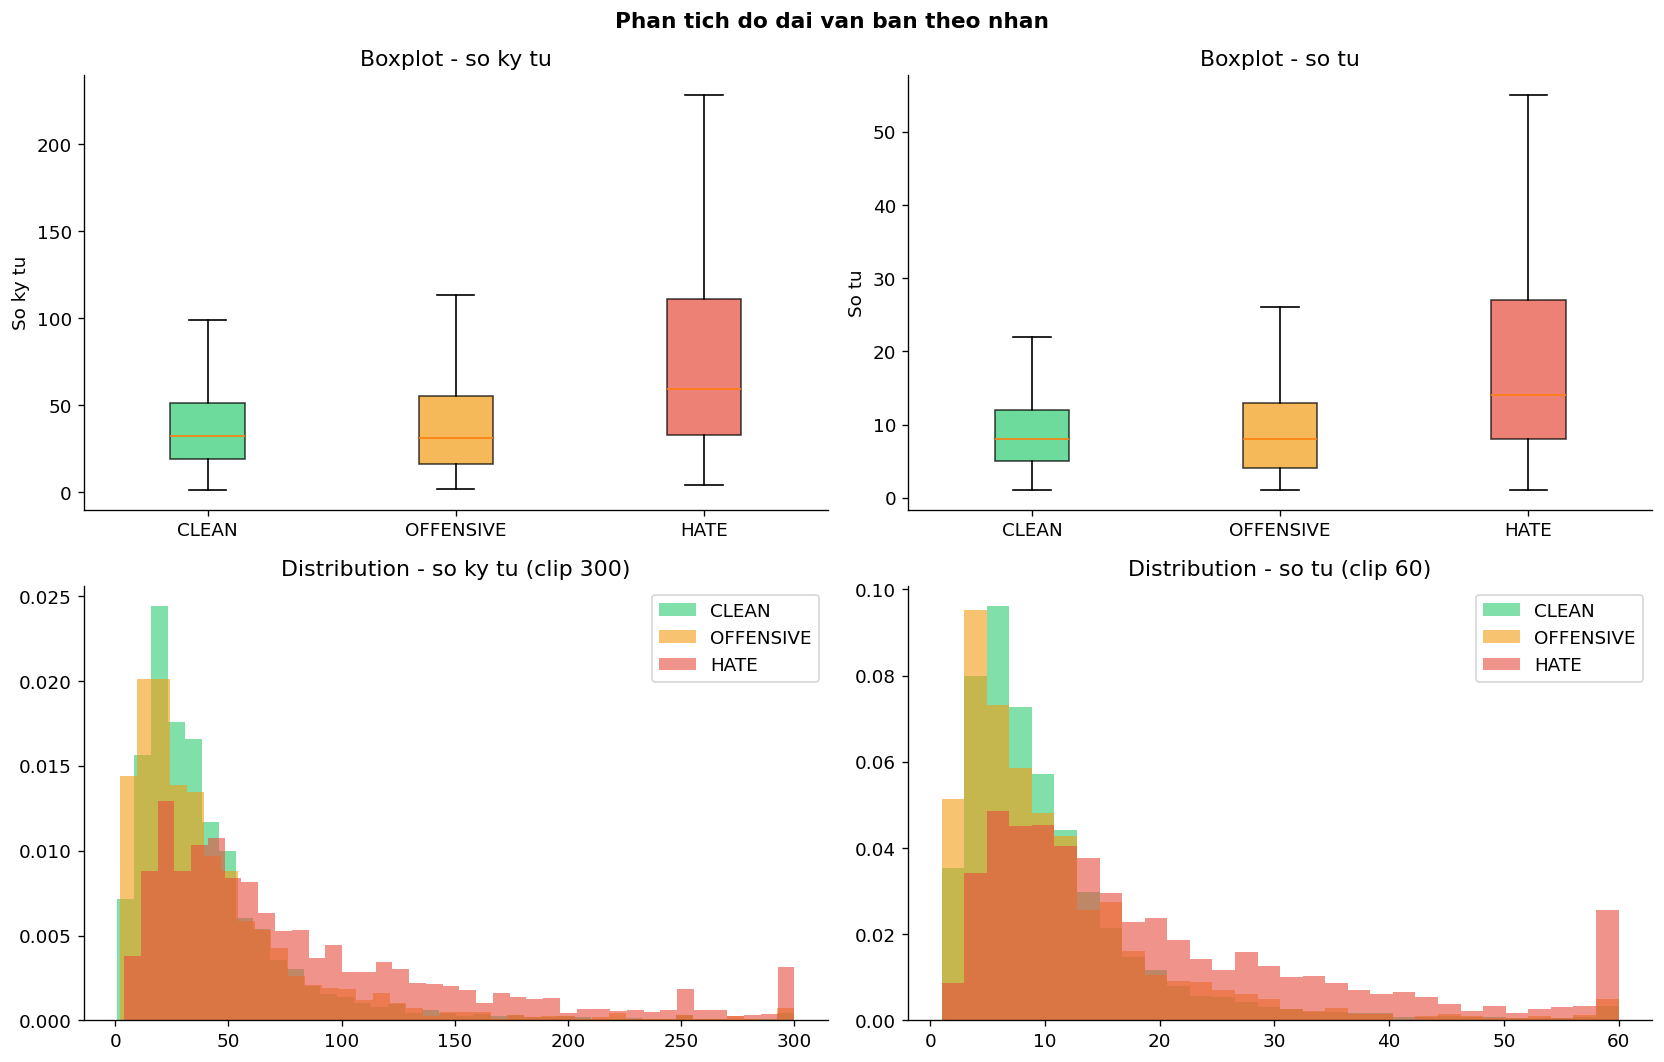

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Phan tich do dai van ban theo nhan', fontsize=13, fontweight='bold')
colors_list = [LABEL_COLORS[l] for l in LABEL_NAMES]

ax = axes[0,0]
data_by_label = [df_train[df_train['label_name']==l]['char_len'].values for l in LABEL_NAMES]
bp = ax.boxplot(data_by_label, labels=LABEL_NAMES, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Boxplot - so ky tu'); ax.set_ylabel('So ky tu')

ax = axes[0,1]
data_by_label_w = [df_train[df_train['label_name']==l]['word_len'].values for l in LABEL_NAMES]
bp2 = ax.boxplot(data_by_label_w, labels=LABEL_NAMES, patch_artist=True, showfliers=False)
for patch, color in zip(bp2['boxes'], colors_list):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Boxplot - so tu'); ax.set_ylabel('So tu')

ax = axes[1,0]
for lbl, color in LABEL_COLORS.items():
    subset = df_train[df_train['label_name']==lbl]['char_len']
    ax.hist(subset.clip(upper=300), bins=40, alpha=0.6, color=color, label=lbl, density=True)
ax.set_title('Distribution - so ky tu (clip 300)'); ax.legend()

ax = axes[1,1]
for lbl, color in LABEL_COLORS.items():
    subset = df_train[df_train['label_name']==lbl]['word_len']
    ax.hist(subset.clip(upper=60), bins=30, alpha=0.6, color=color, label=lbl, density=True)
ax.set_title('Distribution - so tu (clip 60)'); ax.legend()

plt.tight_layout()
plt.savefig('2B_text_length.png', bbox_inches='tight', dpi=120)
plt.show()



### 3 - Dac diem tu vung & Word Cloud

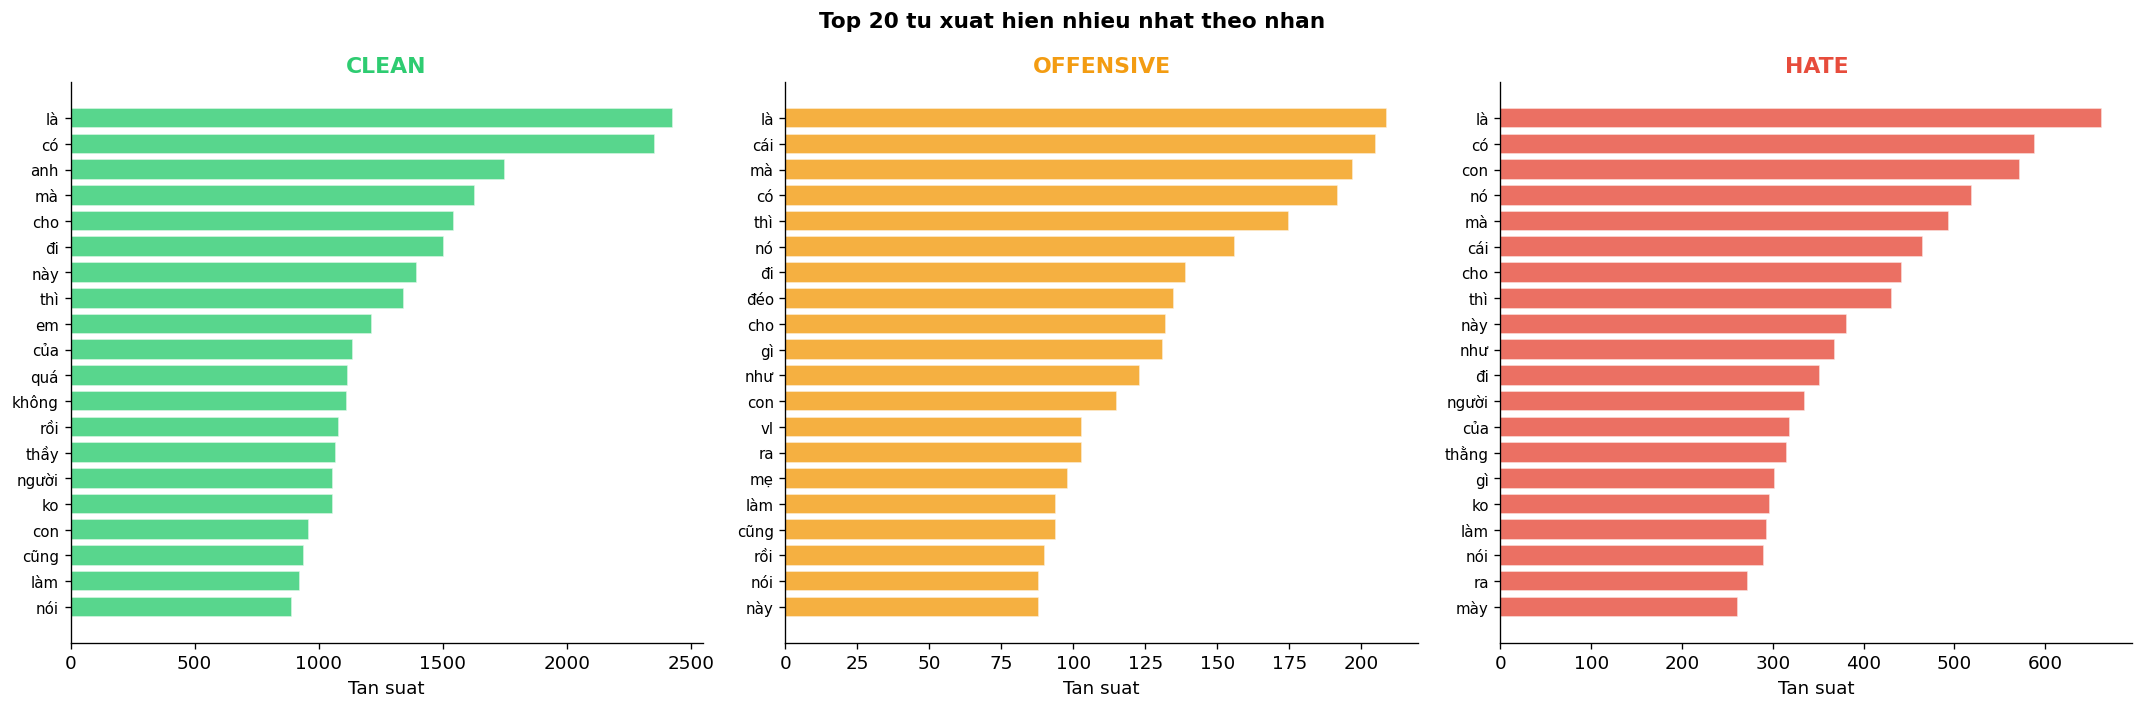

In [10]:
def simple_tokenize(text):
    text = str(text).lower()
    return re.findall(r'[\w]+', text, re.UNICODE)

top_words = {}
for lbl in LABEL_NAMES:
    texts = df_train[df_train['label_name'] == lbl]['text'].tolist()
    all_tokens = []
    for t in texts: all_tokens.extend(simple_tokenize(t))
    top_words[lbl] = Counter(all_tokens).most_common(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 20 tu xuat hien nhieu nhat theo nhan', fontsize=13, fontweight='bold')
for ax, lbl in zip(axes, LABEL_NAMES):
    words, counts = zip(*top_words[lbl])
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color=LABEL_COLORS[lbl], alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos); ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{lbl}', fontweight='bold', color=LABEL_COLORS[lbl])
    ax.set_xlabel('Tan suat')

plt.tight_layout()
plt.savefig('2C_top_words.png', bbox_inches='tight', dpi=120)
plt.show()


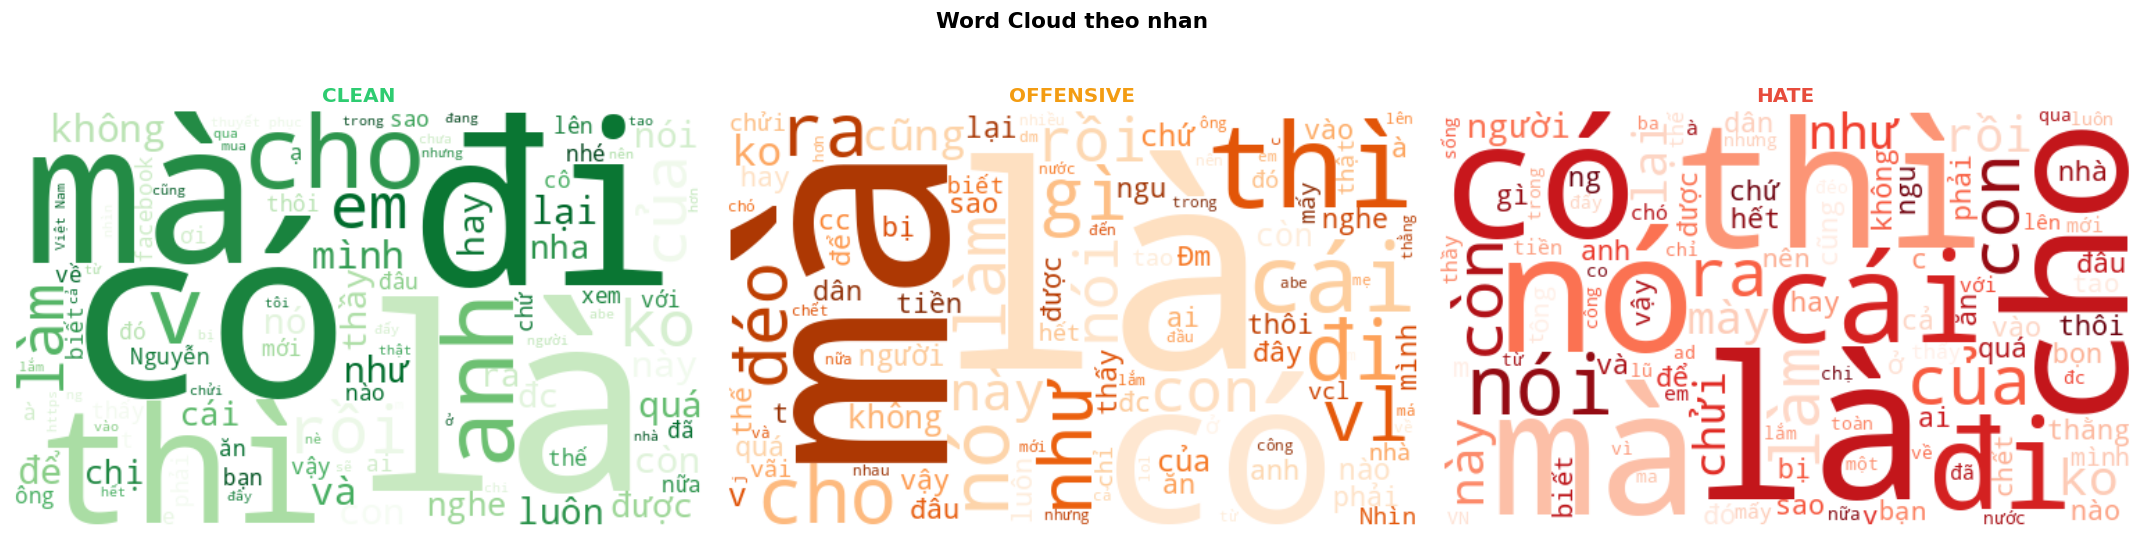

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Cloud theo nhan', fontsize=13, fontweight='bold')
for ax, lbl in zip(axes, LABEL_NAMES):
    texts = ' '.join(df_train[df_train['label_name'] == lbl]['text'].tolist())
    wc = WordCloud(width=500, height=300, background_color='white',
        colormap='Reds' if lbl=='HATE' else ('Oranges' if lbl=='OFFENSIVE' else 'Greens'),
        max_words=100, regexp=r'[\w]+').generate(texts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{lbl}', fontweight='bold', color=LABEL_COLORS[lbl], fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.savefig('2C_wordcloud.png', bbox_inches='tight', dpi=120)
plt.show()


In [12]:
print("Vocabulary size (unique tokens) theo nhan:")
for lbl in LABEL_NAMES:
    texts = df_train[df_train['label_name'] == lbl]['text'].tolist()
    vocab = set()
    for t in texts: vocab.update(simple_tokenize(t))
    print(f"  {lbl:10s}: {len(vocab):,} unique tokens ({len(texts):,} docs)")
all_vocab = set()
for t in df_train['text']: all_vocab.update(simple_tokenize(t))
print(f"  {'TOTAL':10s}: {len(all_vocab):,} unique tokens")


Vocabulary size (unique tokens) theo nhan:
  CLEAN     : 9,577 unique tokens (19,886 docs)
  OFFENSIVE : 2,869 unique tokens (1,606 docs)
  HATE      : 4,355 unique tokens (2,556 docs)
  TOTAL     : 10,683 unique tokens



### 4 - Noise & Dac thu Tieng Viet

In [13]:
patterns = {
    'has_emoji'      : r'[\U00010000-\U0010ffff\U0001F300-\U0001F9FF\u2600-\u26FF\u2700-\u27BF]',
    'has_url'        : r'https?://\S+|www\.\S+',
    'has_mention'    : r'@\w+',
    'has_hashtag'    : r'#\w+',
    'has_repeat_char': r'(.)\1{2,}',
    'has_caps'       : r'[A-Z]{3,}',
    'has_teen_code'  : r'\b(dm|vcl|vl|wtf|omg|lol|vkl|nma|tml)\b',
}
for df in [df_train, df_val, df_test]:
    for feat, pat in patterns.items():
        df[feat] = df['text'].str.contains(pat, flags=re.IGNORECASE, regex=True)

print("Ti le (%) binh luan chua noise theo nhan - Train set:")
print(f"{'Feature':20s}", end='')
for l in LABEL_NAMES: print(f"  {l:10s}", end='')
print(f"  {'ALL':10s}")

for feat in patterns:
    print(f"{feat:20s}", end='')
    for lbl in LABEL_NAMES:
        sub = df_train[df_train['label_name']==lbl]
        print(f"  {sub[feat].mean()*100:8.1f}%", end='')
    print(f"  {df_train[feat].mean()*100:8.1f}%")


Ti le (%) binh luan chua noise theo nhan - Train set:
Feature               CLEAN       OFFENSIVE   HATE        ALL       
has_emoji                 15.5%      10.8%       6.6%      14.3%
has_url                    0.1%       0.0%       0.0%       0.1%
has_mention                0.5%       0.2%       1.1%       0.5%
has_hashtag                0.1%       0.1%       0.1%       0.1%
has_repeat_char           15.4%      15.4%      16.9%      15.6%
has_caps                  78.8%      72.9%      88.1%      79.4%
has_teen_code              1.8%      12.8%       5.6%       3.0%


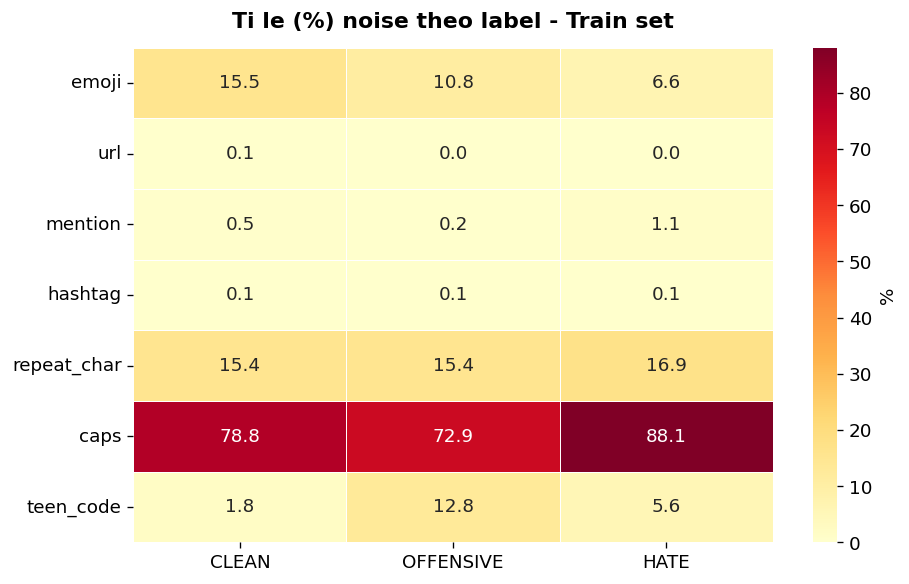

In [14]:
noise_matrix = []
feat_labels = []
for feat in patterns:
    row = [df_train[df_train['label_name']==lbl][feat].mean()*100 for lbl in LABEL_NAMES]
    noise_matrix.append(row)
    feat_labels.append(feat.replace('has_',''))

noise_df = pd.DataFrame(noise_matrix, index=feat_labels, columns=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(noise_df, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax, cbar_kws={'label': '%'})
ax.set_title('Ti le (%) noise theo label - Train set', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('2D_noise_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()


### 5 - N-gram Analysis

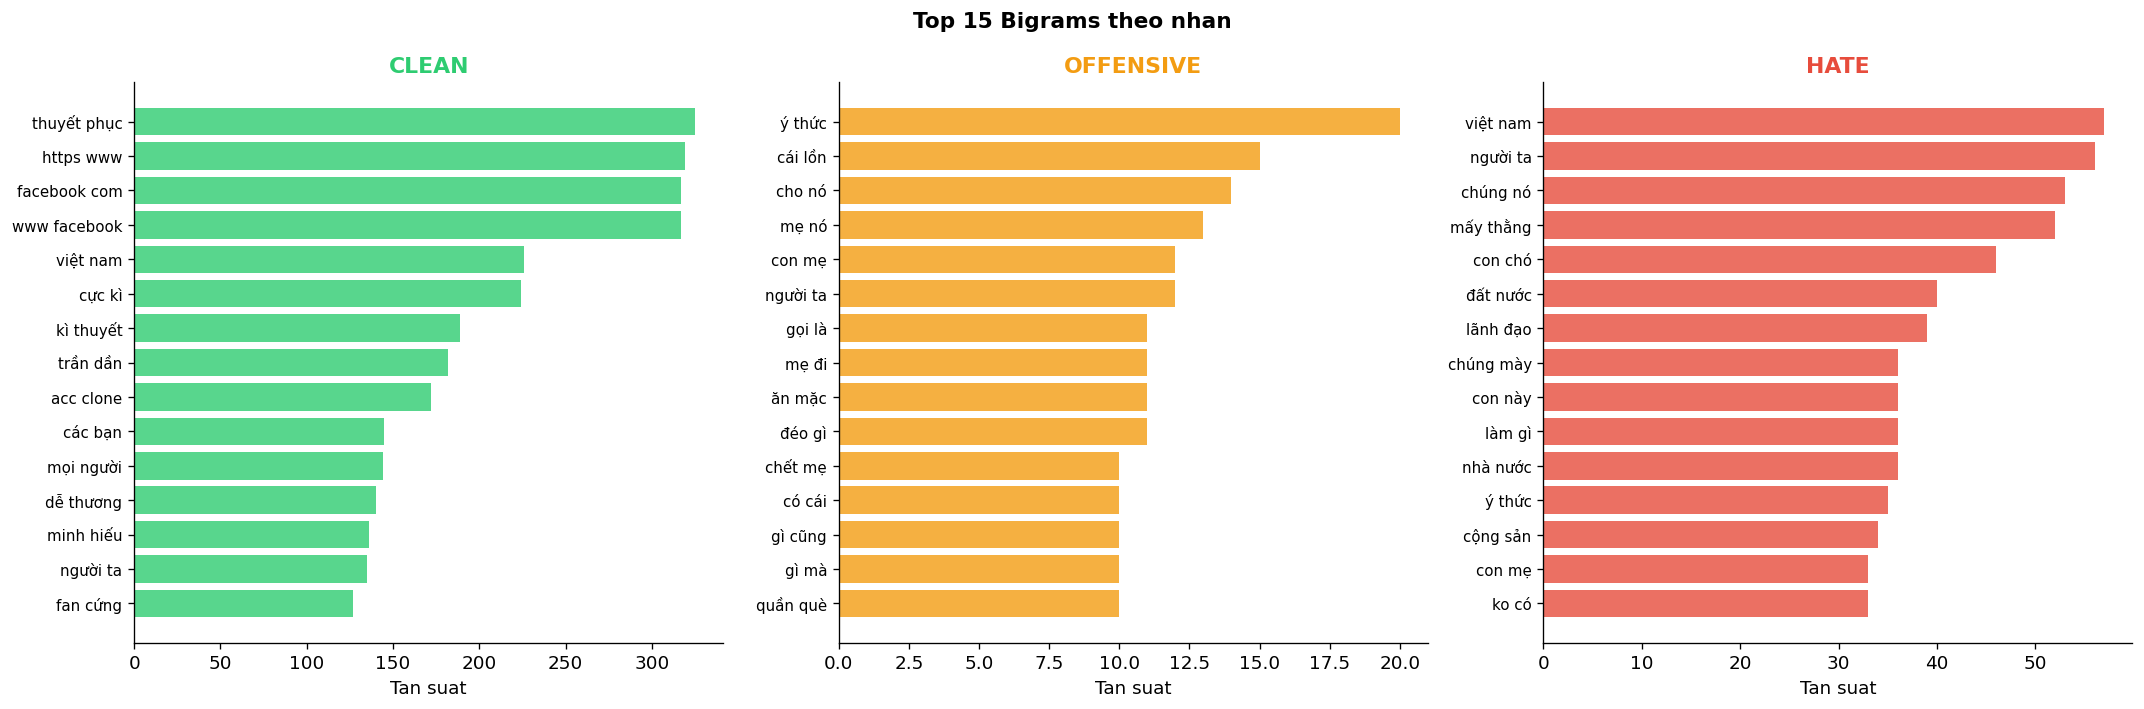

In [15]:
def get_ngrams(texts, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n,n), max_features=5000, token_pattern=r'[\w]+', min_df=2)
    X = vec.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return sorted(zip(vocab, freqs), key=lambda x: -x[1])[:top_k]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 15 Bigrams theo nhan', fontsize=13, fontweight='bold')
for ax, lbl in zip(axes, LABEL_NAMES):
    texts = df_train[df_train['label_name']==lbl]['text'].tolist()
    bigrams = get_ngrams(texts, n=2, top_k=15)
    if bigrams:
        grams, counts = zip(*bigrams)
        y_pos = range(len(grams))
        ax.barh(y_pos, counts, color=LABEL_COLORS[lbl], alpha=0.8)
        ax.set_yticks(y_pos); ax.set_yticklabels(grams, fontsize=9)
        ax.invert_yaxis()
    ax.set_title(f'{lbl}', fontweight='bold', color=LABEL_COLORS[lbl])
    ax.set_xlabel('Tan suat')
plt.tight_layout()
plt.savefig('2E_bigrams.png', bbox_inches='tight', dpi=120)
plt.show()


In [16]:
vec_chi = CountVectorizer(max_features=3000, token_pattern=r'[\w]+', min_df=3)
X_chi   = vec_chi.fit_transform(df_train['text'])
y_chi   = df_train['label'].values
feature_names = vec_chi.get_feature_names_out()
chi2_scores, _ = chi2(X_chi, y_chi)
top_idx = np.argsort(chi2_scores)[-20:][::-1]

print("Top 20 tu co chi-square score cao nhat:")
print(f"{'Tu':20s}  {'Chi2':>12}")

for i in top_idx:
    print(f"  {feature_names[i]:18s}  {chi2_scores[i]:12.1f}")


Top 20 tu co chi-square score cao nhat:
Tu                            Chi2
  thằng                     1293.7
  ngu                       1106.6
  mày                       1104.2
  nó                        1068.8
  con                       1015.3
  chó                       1004.7
  đéo                        900.9
  bọn                        855.9
  cái                        841.8
  mẹ                         740.0
  lồn                        688.9
  dân                        605.4
  lũ                         601.5
  bò                         491.5
  cc                         471.8
  đm                         447.8
  như                        441.2
  chúng                      383.4
  nước                       377.2
  lol                        343.9


### 6 - Chat luong Du lieu

In [17]:
print("  KIEM TRA CHAT LUONG DU LIEU")
for split_name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    print(f"\n[{split_name}]")
    null_count  = df['text'].isna().sum()
    empty_count = (df['text'].str.strip() == '').sum()
    dup_exact   = df.duplicated(subset=['text']).sum()
    conflict_count = (df.groupby('text')['label'].nunique() > 1).sum()
    q1, q3 = df['char_len'].quantile([0.01, 0.99])
    outlier_short = (df['char_len'] < 3).sum()
    outlier_long  = (df['char_len'] > q3).sum()
    print(f"  Null values      : {null_count}")
    print(f"  Empty strings    : {empty_count}")
    print(f"  Exact duplicates : {dup_exact} ({dup_exact/len(df)*100:.2f}%)")
    print(f"  Label conflicts  : {conflict_count}")
    print(f"  Qua ngan (<3 ky tu): {outlier_short}")
    print(f"  Qua dai (>P99={q3:.0f}): {outlier_long}")


  KIEM TRA CHAT LUONG DU LIEU

[Train]
  Null values      : 0
  Empty strings    : 0
  Exact duplicates : 1490 (6.20%)
  Label conflicts  : 132
  Qua ngan (<3 ky tu): 170
  Qua dai (>P99=253): 241

[Val]
  Null values      : 0
  Empty strings    : 0
  Exact duplicates : 22 (0.82%)
  Label conflicts  : 1
  Qua ngan (<3 ky tu): 28
  Qua dai (>P99=255): 27

[Test]
  Null values      : 0
  Empty strings    : 0
  Exact duplicates : 104 (1.56%)
  Label conflicts  : 6
  Qua ngan (<3 ky tu): 56
  Qua dai (>P99=258): 67


## Data Preprocessing

In [18]:
# 1. SUPER TEEN_CODE_DICT (Đã gộp list của bạn + mở rộng)
TEEN_CODE_DICT = {
    # PROFANITY (core + biến thể)
    "dm":"dit me","dmm":"dit me","dmmm":"dit me","dmn":"dit me","dmnn":"dit me",
    "dcm":"dit con me","dkm":"dit me","duma":"dit me",
    "cl":"lon","clm":"cai lon me","clmm":"cai lon me",
    "vl":"vai lon","vcl":"vai ca lon","vkl":"vai lon","vlon":"vai lon",
    "cc":"con cac","cmm":"con me may","ccm":"con cac me",
    "lol":"lon","loz":"lon","l":"lon","lz":"lon",
    "dit":"dit","lon":"lon","cac":"cac",
    "tml":"to me lon", # <- Thêm từ của bạn

    # EXTREME SLANG
    "vlll":"vai lon","vllll":"vai lon","vcll":"vai ca lon",
    "dmmmm":"dit me","cllll":"lon","ccccc":"con cac",

    # KHÔNG
    "ko":"khong","k":"khong","kh":"khong",
    "hok":"khong","hông":"khong","khum":"khong","hem":"khong",
    "k0":"khong","kg":"khong","hong":"khong",

    # NGỮ PHÁP / NỐI TỪ
    "dc":"duoc","đc":"duoc","dk":"duoc","đk":"duoc",
    "vs":"voi","v":"voi",
    "r":"roi","roi":"roi","roii":"roi","ròi":"roi","rùi":"roi",
    "nma":"nhung ma","nmaaa":"nhung ma","nhma":"nhung ma",
    "cx":"cung","cug":"cung","cũng":"cung",
    "ms":"moi",

    # ĐẠI TỪ
    "t":"toi","mk":"minh","mik":"minh","m":"may",
    "b":"ban","ae":"anh em","mn":"moi nguoi","tụi":"chung toi",

    # TIẾNG ANH LÓNG
    "wtf":"cai quai","omg":"oi troi",
    "lolol":"lon","lmao":"cuoi chet","bruh":"that a",

    # TÍCH CỰC & KHÁC
    "ok":"tot","oke":"on","okie":"on","okela":"on","oce":"on",
    "good":"tot","nice":"tot",
    "bt":"binh thuong","nx":"nua","ns":"noi",
    "tks":"cam on","thx":"cam on","pls":"lam on","plz":"lam on"
}

# 2. SUPER STOPWORDS (ĐÃ BỎ "KHÔNG", "RẤT", "QUÁ" ĐỂ BẢO TOÀN SENTIMENT)
VN_STOPWORDS = {
    # Từ nối, đại từ, chỉ từ yếu (Giữ lại list cũ của bạn, bỏ các từ nhạy cảm)
    "va","la","cua","co","trong","da","duoc","cho","voi",
    "cac","mot","nhung","nay","do","nguoi","ve","hay","thi",
    "tu","nhu","con","khi","vi","cung","ma","den","lai",
    "ra","di","len","xuong","vao","qua","tren","duoi",
    "nen","theo","tai","the","cai",

    # Từ đệm (Filler)
    "a","oi","u","uh","uhm","um","ah",
    "nhe","nhi","thoi","ha","he","ne",

    # Từ để hỏi (Question)
    "nao","gi","ai","sao","day","kia",

    # Cấu trúc bị động / chung chung
    "bi","boi","do","de","lam","noi","biet",

    # Từ mang tính biểu đạt nhẹ
    "that","thuc","su","vay","thay",

    # Âm thanh (Spoken noise)
    "ahh","uhh","hmm","huhu","haha","hehe","kkk","kk","hi","hihi"
}

print(f"Teen code dict (Final): {len(TEEN_CODE_DICT)} entries")
print(f"VN stopwords (Final - Safe for Sentiment): {len(VN_STOPWORDS)} words")

Teen code dict (Final): 87 entries
VN stopwords (Final - Safe for Sentiment): 80 words


In [19]:
def normalize_unicode(text):
    text = unicodedata.normalize('NFC', str(text))
    return text.lower().strip()

def remove_noise(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    emoji_pattern = re.compile(
        '[\U00010000-\U0010ffff\U0001F300-\U0001F9FF\u2600-\u26FF\u2700-\u27BF]+',
        flags=re.UNICODE)
    return emoji_pattern.sub(' ', text)

def clean_special_chars(text):
    text = re.sub(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_repeat(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

def normalize_text_regex(text):
    text = re.sub(r'\bd+m+\b', 'dm', text)
    text = re.sub(r'\bv+l+\b', 'vl', text)
    text = re.sub(r'\bc+c+\b', 'cc', text)
    text = re.sub(r'\bd+k+m+\b', 'dkm', text)
    text = re.sub(r'\bv+c+l+\b', 'vcl', text)
    text = re.sub(r'\bc+l+m+\b', 'clm', text)
    return text

def expand_teen_code(text):
    words = text.split()
    return ' '.join([TEEN_CODE_DICT.get(w, w) for w in words])

def vn_tokenize_text(text):
    try:
        return vn_tokenize(text, format='text')
    except Exception:
        return text

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in VN_STOPWORDS and len(w) > 1])

def full_preprocess(text, use_tokenizer=True):
    text = normalize_unicode(text)
    text = remove_noise(text)
    text = clean_special_chars(text)
    text = normalize_repeat(text)
    text = normalize_text_regex(text)

    text = expand_teen_code(text)

    if use_tokenizer:
        text = vn_tokenize_text(text)

    text = remove_stopwords(text)
    return text.strip()

samples = [
    "Dmm may ngu vclllll luan y!!! @nguoidung",
    "Bai hat hay qua a https://yt.be/xxx",
    "Lu quan ngai di cho khac di cho thoang",
    "đmmmmmmm tml này làm cc gì vây???"
]

print("Demo preprocessing:")
for s in samples:
    print(f"  Truoc: {s}")
    print(f"  Sau  : {full_preprocess(s, use_tokenizer=False)}")

Demo preprocessing:
  Truoc: Dmm may ngu vclllll luan y!!! @nguoidung
  Sau  : dit me may ngu vai ca lon luan
  Truoc: Bai hat hay qua a https://yt.be/xxx
  Sau  : bai hat
  Truoc: Lu quan ngai di cho khac di cho thoang
  Sau  : lu quan ngai khac thoang
  Truoc: đmmmmmmm tml này làm cc gì vây???
  Sau  : đm to me lon này làm gì vây


In [20]:
USE_VN_TOKENIZER = True

for split_name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    t0 = time.time()

    df['text_clean'] = df['text'].apply(
        lambda x: full_preprocess(x, use_tokenizer=USE_VN_TOKENIZER))

    df['text_clean'] = df['text_clean'].replace('', np.nan)
    n_empty = df['text_clean'].isna().sum()
    df.dropna(subset=['text_clean'], inplace=True)

    df.reset_index(drop=True, inplace=True)

    print(f"  [{split_name}] Xong trong {time.time()-t0:.1f}s | Loai {n_empty} dong rong")

print(f"\nPreprocessing hoan tat!")
print(f"   Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

  [Train] Xong trong 14.6s | Loai 338 dong rong
  [Val] Xong trong 1.5s | Loai 39 dong rong
  [Test] Xong trong 8.5s | Loai 104 dong rong

Preprocessing hoan tat!
   Train: 23,710 | Val: 2,633 | Test: 6,576



## EDA Sau Preprocessing

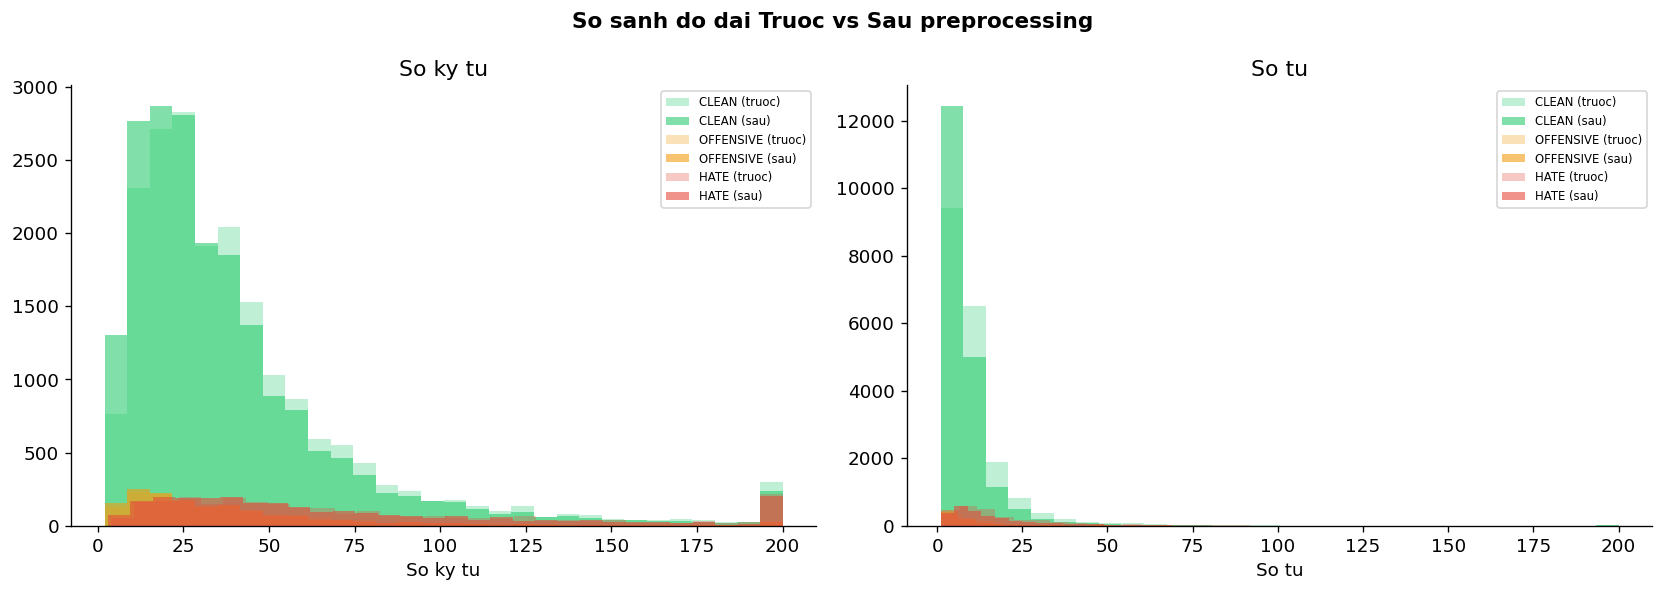

  Trung binh ky tu: 49.9 -> 44.1  (giam 11.7%)
  Trung binh tu: 11.7 -> 8.8  (giam 24.1%)


In [21]:
df_train['char_len_clean'] = df_train['text_clean'].apply(len)
df_train['word_len_clean'] = df_train['text_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So sanh do dai Truoc vs Sau preprocessing', fontsize=13, fontweight='bold')

for ax, (col_before, col_after, title) in zip(axes, [
    ('char_len', 'char_len_clean', 'So ky tu'),
    ('word_len', 'word_len_clean', 'So tu'),
]):
    for lbl, color in LABEL_COLORS.items():
        sub = df_train[df_train['label_name'] == lbl]
        ax.hist(sub[col_before].clip(upper=200), bins=30, alpha=0.3, color=color, label=f'{lbl} (truoc)')
        ax.hist(sub[col_after].clip(upper=200),  bins=30, alpha=0.6, color=color, label=f'{lbl} (sau)')
    ax.set_title(title); ax.set_xlabel(title); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('4_before_after_length.png', bbox_inches='tight', dpi=120)
plt.show()

for col_b, col_a, name in [('char_len','char_len_clean','ky tu'), ('word_len','word_len_clean','tu')]:
    avg_b = df_train[col_b].mean()
    avg_a = df_train[col_a].mean()
    print(f"  Trung binh {name}: {avg_b:.1f} -> {avg_a:.1f}  (giam {(avg_b-avg_a)/avg_b*100:.1f}%)")


In [22]:
print("Noise con sot sau preprocessing (train set):")
for feat, pat in patterns.items():
    before = df_train[feat].mean() * 100
    after  = df_train['text_clean'].str.contains(pat, flags=re.IGNORECASE, regex=True, na=False).mean() * 100
    delta  = before - after
    status = 'OK' if delta > before * 0.5 else 'WARN'
    print(f"  [{status}] {feat:20s}: {before:5.1f}% -> {after:5.1f}%  (giam {delta:.1f}%)")


Noise con sot sau preprocessing (train set):
  [OK] has_emoji           :  13.7% ->   0.0%  (giam 13.7%)
  [OK] has_url             :   0.1% ->   0.0%  (giam 0.1%)
  [OK] has_mention         :   0.5% ->   0.0%  (giam 0.5%)
  [OK] has_hashtag         :   0.0% ->   0.0%  (giam 0.0%)
  [OK] has_repeat_char     :  15.4% ->   0.0%  (giam 15.4%)
  [WARN] has_caps            :  80.3% ->  79.6%  (giam 0.6%)
  [OK] has_teen_code       :   3.0% ->   0.0%  (giam 3.0%)


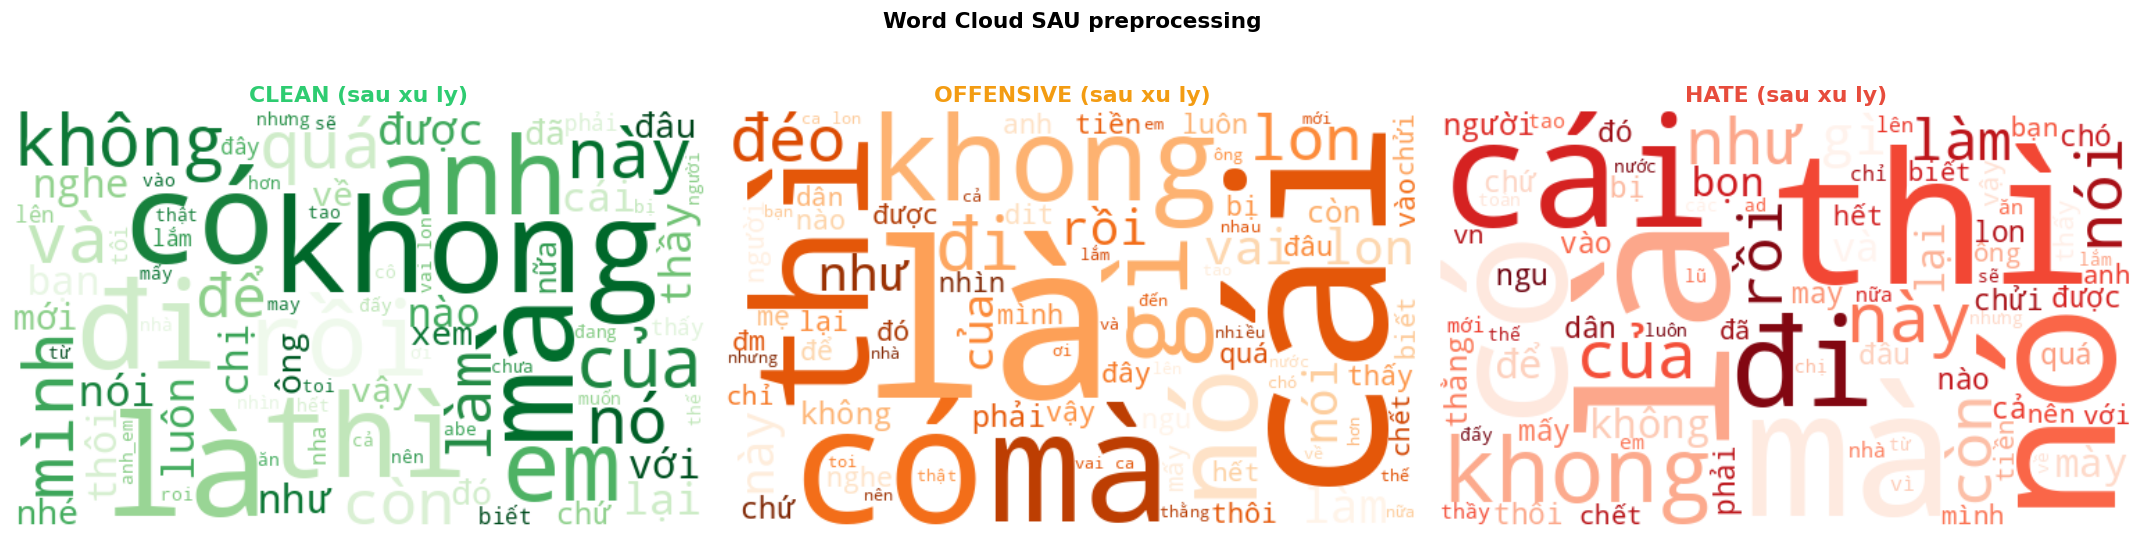

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Cloud SAU preprocessing', fontsize=13, fontweight='bold')
for ax, lbl in zip(axes, LABEL_NAMES):
    texts = ' '.join(df_train[df_train['label_name'] == lbl]['text_clean'].dropna().tolist())
    if not texts.strip():
        ax.text(0.5, 0.5, 'No data', ha='center'); continue
    wc = WordCloud(width=500, height=300, background_color='white',
        colormap='Reds' if lbl=='HATE' else ('Oranges' if lbl=='OFFENSIVE' else 'Greens'),
        max_words=80, regexp=r'[\w_]+').generate(texts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{lbl} (sau xu ly)', fontweight='bold', color=LABEL_COLORS[lbl])
    ax.axis('off')
plt.tight_layout()
plt.savefig('4_wordcloud_after.png', bbox_inches='tight', dpi=120)
plt.show()


---
##  Feature Engineering

| Nhom | Ky thuat | Ghi chu |
|------|----------|---------|
| **TF-IDF** | Unigram + Bigram | Xuong song cua pipeline |
| **LDA** | Topic distribution | Them ngu nghia chu de |
| **Lexicon** | Dem tu tuc tuu, sentiment | Domain knowledge |
| **Statistical** | Do dai, emoji, caps... | Tin hieu hanh vi |


In [24]:
print("Fitting TF-IDF")
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), max_features=30000, min_df=2, max_df=0.95,
    sublinear_tf=True, token_pattern=r'[\w_]+')
X_tfidf_train = tfidf.fit_transform(df_train['text_clean'].fillna(''))
X_tfidf_val   = tfidf.transform(df_val['text_clean'].fillna(''))
X_tfidf_test  = tfidf.transform(df_test['text_clean'].fillna(''))
print(f"TF-IDF shape: {X_tfidf_train.shape} | Vocab: {len(tfidf.vocabulary_):,}")


Fitting TF-IDF
TF-IDF shape: (23710, 30000) | Vocab: 30,000


In [25]:
print("Fitting LDA")
count_vec = CountVectorizer(max_features=10000, min_df=3, token_pattern=r'[\w_]+')
X_count_train = count_vec.fit_transform(df_train['text_clean'].fillna(''))
N_TOPICS = 10
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=SEED, max_iter=20,
                                 learning_method='online', n_jobs=-1)
X_lda_train = lda.fit_transform(X_count_train)
X_lda_val   = lda.transform(count_vec.transform(df_val['text_clean'].fillna('')))
X_lda_test  = lda.transform(count_vec.transform(df_test['text_clean'].fillna('')))
print(f"LDA shape: {X_lda_train.shape} | Perplexity: {lda.perplexity(X_count_train):.1f}")

print("\nTop 8 tu trong moi topic:")
vocab_lda = count_vec.get_feature_names_out()
for i, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[-8:][::-1]
    print(f"  Topic {i:2d}: {', '.join([vocab_lda[j] for j in top_idx])}")


Fitting LDA
LDA shape: (23710, 10) | Perplexity: 1631.0

Top 8 tu trong moi topic:
  Topic  0: gì, cái, là, lon, nói, này, đây, thì
  Topic  1: mà, làm, thằng, này, nhiều, nó, xem, mấy
  Topic  2: nó, ơi, quá, cô, nào, có, thấy, mà
  Topic  3: anh, ba, vậy, tôi, năm, rồi, nghe, nhé
  Topic  4: bạn, các, thôi, lên, như, đi, chỉ, có
  Topic  5: thầy, chị, nha, hơn, chi, tao, mày, quá
  Topic  6: có, là, người, của, không, khong, mà, luôn
  Topic  7: đi, đâu, về, ông, trần, abe, yêu, nữa
  Topic  8: chửi, may, thật, vn, khong, cười, cứ, toi
  Topic  9: tiền, xin, nhìn, với, sẽ, dân, phải, nước


In [26]:
TOXIC_WORDS = set([
    'chet','giet','ngu','dan','vo hoc','suc vat','thoi','hen','khon','ban','rac',
    'may','tao','chung may','bon','lu','do','thang','con',
    'ghet','kinh','cam','thu','tom','xau xa',
] + list(TEEN_CODE_DICT.keys()))

def extract_lexicon_features(texts):
    feats = []
    for text in texts:
        words = str(text).lower().split()
        toxic_cnt = sum(1 for w in words if w in TOXIC_WORDS)
        total_words = max(len(words), 1)
        feats.append([toxic_cnt, toxic_cnt/total_words, sum(1 for w in words if len(w)>8)])
    return np.array(feats, dtype=np.float32)

X_lex_train = extract_lexicon_features(df_train['text_clean'].fillna(''))
X_lex_val   = extract_lexicon_features(df_val['text_clean'].fillna(''))
X_lex_test  = extract_lexicon_features(df_test['text_clean'].fillna(''))
print(f"Lexicon features: {X_lex_train.shape} | [toxic_count, toxic_ratio, long_words]")


Lexicon features: (23710, 3) | [toxic_count, toxic_ratio, long_words]


In [27]:
def extract_stat_features(df):
    feats = pd.DataFrame()
    text       = df['text'].astype(str)
    text_clean = df['text_clean'].fillna('').astype(str)
    feats['char_len']       = text.apply(len)
    feats['word_count']     = text_clean.apply(lambda x: len(x.split()))
    feats['avg_word_len']   = text_clean.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    feats['exclaim_count']  = text.str.count(r'!')
    feats['question_count'] = text.str.count(r'\?')
    feats['caps_ratio']     = text.apply(lambda x: sum(1 for c in x if c.isupper())/max(len(x),1))
    feats['digit_ratio']    = text.apply(lambda x: sum(1 for c in x if c.isdigit())/max(len(x),1))
    feats['has_url']        = text.str.contains(r'https?://', regex=True).astype(int)
    feats['has_mention']    = text.str.contains(r'@\w+', regex=True).astype(int)
    feats['repeat_char']    = text.str.contains(r'(.)\1{2,}', regex=True).astype(int)
    return feats.values.astype(np.float32)

X_stat_train = extract_stat_features(df_train)
X_stat_val   = extract_stat_features(df_val)
X_stat_test  = extract_stat_features(df_test)
print(f"Statistical features: {X_stat_train.shape}")


Statistical features: (23710, 10)


In [28]:
X_train = hstack([X_tfidf_train, csr_matrix(X_lda_train), csr_matrix(X_lex_train), csr_matrix(X_stat_train)])
X_val   = hstack([X_tfidf_val,   csr_matrix(X_lda_val),   csr_matrix(X_lex_val),   csr_matrix(X_stat_val)])
X_test  = hstack([X_tfidf_test,  csr_matrix(X_lda_test),  csr_matrix(X_lex_test),  csr_matrix(X_stat_test)])

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f"Final feature matrix:")
print(f"  X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"  TF-IDF: {X_tfidf_train.shape[1]:,} | LDA: {N_TOPICS} | Lex: {X_lex_train.shape[1]} | Stat: {X_stat_train.shape[1]}")


Final feature matrix:
  X_train: (23710, 30023) | X_val: (2633, 30023) | X_test: (6576, 30023)
  TF-IDF: 30,000 | LDA: 10 | Lex: 3 | Stat: 10


In [29]:
print("Chi-square feature selection...")
selector = SelectKBest(chi2, k=15000)
X_train_sel = selector.fit_transform(X_train, y_train)
X_val_sel   = selector.transform(X_val)
X_test_sel  = selector.transform(X_test)
print(f"Sau SelectKBest: {X_train.shape[1]:,} -> {X_train_sel.shape[1]:,} features")


Chi-square feature selection...
Sau SelectKBest: 30,023 -> 15,000 features



## Model Training & Hyperparameter Tuning

**Chien luoc:**
- **Stratified 5-Fold CV** de danh gia khach quan
- **Metric chinh**: Macro F1 (khong dung Accuracy vi data mat can bang)
- Tat ca models dung `class_weight='balanced'`
- Hyperparameter tuning voi **GridSearchCV**


> Khởi tạo cấu hình và dictionary lưu kết quả

In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
trained_models = {}

def save_result(name, scores=None, mean=None, std=None, time_used=None, model=None):
    if scores is not None:
        mean = scores.mean()
        std  = scores.std()

    cv_results[name] = {
        'scores': scores,
        'mean'  : mean,
        'std'   : std,
        'time'  : time_used
    }
    trained_models[name] = model

    print(f"DONE: {name:25s} | F1: {mean:.4f} | Time: {time_used:.1f}s")

### MultinomialNB

In [31]:
name = 'MultinomialNB'
model = MultinomialNB(alpha=0.1)

t0 = time.time()
scores = cross_val_score(model, X_train_sel, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
model.fit(X_train_sel, y_train)

MultinomialNB(alpha=0.1)

In [32]:
elapsed = time.time() - t0
cv_results[name] = {'scores': scores, 'mean': scores.mean(), 'std': scores.std(), 'time': elapsed}
trained_models[name] = model

print(f"DONE: {name:20s} | CV F1: {scores.mean():.4f} | Time: {elapsed:.1f}s")

DONE: MultinomialNB        | CV F1: 0.5969 | Time: 0.1s


### LinearSVM

In [33]:
name = 'LinearSVM'
gs_svm = GridSearchCV(
    LinearSVC(max_iter=2000, class_weight='balanced', random_state=SEED),
    {'C': [0.001, 0.01, 0.1, 0.5, 1.0]},
    cv=skf, scoring='f1_macro', n_jobs=-1
)

In [34]:
t0 = time.time()
gs_svm.fit(X_train_sel, y_train)
elapsed = time.time() - t0

In [35]:
trained_models[name] = gs_svm.best_estimator_
cv_results[name] = {'mean': gs_svm.best_score_, 'time': elapsed}

print(f"DONE: {name:20s} | Best C: {gs_svm.best_params_['C']} | CV F1: {gs_svm.best_score_:.4f}")

DONE: LinearSVM            | Best C: 0.5 | CV F1: 0.6320


### LogisticRegression

In [36]:
name = 'LogisticRegression'
gs_lr = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced',
                       random_state=SEED, multi_class='multinomial'),
    {'C': [0.001, 0.01, 0.1, 0.5, 1.0]},
    cv=skf, scoring='f1_macro', n_jobs=-1
)

In [37]:
t0 = time.time()
gs_lr.fit(X_train_sel, y_train)
elapsed = time.time() - t0

In [38]:
trained_models[name] = gs_lr.best_estimator_
cv_results[name] = {'mean': gs_lr.best_score_, 'time': elapsed}

print(f"DONE: {name:20s} | Best C: {gs_lr.best_params_['C']} | CV F1: {gs_lr.best_score_:.4f}")

DONE: LogisticRegression   | Best C: 1.0 | CV F1: 0.6120


### XGBoost

In [39]:
name = 'XGBoost'
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1)

In [40]:
t0 = time.time()
scores = cross_val_score(model, X_train_sel, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
model.fit(X_train_sel, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [41]:
cv_results[name] = {'mean': scores.mean(), 'time': time.time() - t0}
trained_models[name] = model
print(f"DONE: {name:20s} | CV F1: {scores.mean():.4f}")

DONE: XGBoost              | CV F1: 0.5477


### LightGBM

In [42]:
name = 'LightGBM'
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1)

In [43]:
t0 = time.time()
scores = cross_val_score(model, X_train_sel, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
model.fit(X_train_sel, y_train)

LGBMClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
               random_state=42, verbose=-1)

In [44]:
cv_results[name] = {'mean': scores.mean(), 'time': time.time() - t0}
trained_models[name] = model
print(f"DONE: {name:20s} | CV F1: {scores.mean():.4f}")

DONE: LightGBM             | CV F1: 0.5854


### CatBoost

In [45]:
name = 'CatBoost'
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=SEED,
    verbose=0,
    thread_count=-1)

In [46]:
t0 = time.time()
scores = cross_val_score(model, X_train_sel, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
model.fit(X_train_sel, y_train)

CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=200, learning_rate=0.1, random_seed=42, verbose=0)

In [47]:
cv_results[name] = {'mean': scores.mean(), 'time': time.time() - t0}
trained_models[name] = model
print(f"DONE: {name:20s} | CV F1: {scores.mean():.4f}")

DONE: CatBoost             | CV F1: 0.5240



### Tinh chỉnh Ngưỡng Quyết Định (Threshold Tuning) cho TOÀN BỘ MODEL
Tự động lấy xác suất và thử nghiệm nhiều cặp ngưỡng khác nhau trên tất cả các thuật toán.

In [54]:
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

print("\n--- BẮT ĐẦU TÌM KIẾM NGƯỠNG TỐI ƯU CHO TOÀN BỘ CÁC MODEL ---")

# 1. Hàm dự đoán với ngưỡng tùy chỉnh
def predict_with_threshold(model, X, threshold_hate, threshold_off):
    probas = model.predict_proba(X)
    predictions = []

    # 0: CLEAN, 1: OFFENSIVE, 2: HATE
    for prob in probas:
        prob_clean, prob_off, prob_hate = prob[0], prob[1], prob[2]

        # Ưu tiên 1: Bắt HATE
        if prob_hate >= threshold_hate:
            predictions.append(2)
        # Ưu tiên 2: Bắt OFFENSIVE
        elif prob_off >= threshold_off:
            predictions.append(1)
        # Còn lại: Mặc định là CLEAN
        else:
            predictions.append(0)

    return np.array(predictions)

# 2. Lớp mô hình ảo bọc lấy thuật toán tinh chỉnh ngưỡng
class CustomThresholdModel:
    def __init__(self, base_model, t_hate, t_off):
        self.model = base_model
        self.t_hate = t_hate
        self.t_off = t_off

    def predict(self, X):
        return predict_with_threshold(self.model, X, self.t_hate, self.t_off)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

# 3. Khởi tạo danh sách các ngưỡng muốn thử nghiệm
thresholds_to_test = [
    {'hate': 0.40, 'off': 0.40},
    {'hate': 0.35, 'off': 0.35},
    {'hate': 0.30, 'off': 0.35}, # Ưu tiên bắt HATE mạnh hơn
    {'hate': 0.25, 'off': 0.30}, # Bắt rất gắt (dễ làm tăng False Positives)
]

# 4. Duyệt qua danh sách các model gốc đã train
# Dùng list() để tạo bản sao, tránh lỗi runtime khi thêm item mới vào dict đang lặp
original_models = list(trained_models.items())

for name, base_model in original_models:
    # Bỏ qua nếu bản thân nó đã là mô hình tuned (tránh lặp vô hạn nếu lỡ chạy cell 2 lần)
    if "_Tuned" in name:
        continue

    print(f"Đang xử lý ngưỡng cho: {name:20s} ... ", end="")

    # Kiểm tra xem model có sẵn predict_proba không
    if not hasattr(base_model, "predict_proba"):
        # Chỉ LinearSVC cần bọc lại
        prob_model = CalibratedClassifierCV(base_model, cv='prefit')
        prob_model.fit(X_train_sel, y_train)
    else:
        # Các model khác (LR, XGBoost, LightGBM...) dùng thẳng
        prob_model = base_model

    # Thêm các phiên bản đã tinh chỉnh ngưỡng vào danh sách đánh giá
    count = 0
    for t in thresholds_to_test:
        t_h = t['hate']
        t_o = t['off']
        model_name = f"{name}_Tuned(H:{t_h}_O:{t_o})"
        trained_models[model_name] = CustomThresholdModel(prob_model, t_hate=t_h, t_off=t_o)
        count += 1

    print(f"Thêm {count} cấu hình.")

print("\nĐã hoàn tất! Sẵn sàng để đánh giá (Evaluation) TẤT CẢ các cấu hình ngưỡng.")


--- BẮT ĐẦU TÌM KIẾM NGƯỠNG TỐI ƯU CHO TOÀN BỘ CÁC MODEL ---
Đang xử lý ngưỡng cho: MultinomialNB        ... Thêm 4 cấu hình.
Đang xử lý ngưỡng cho: LinearSVM            ... Thêm 4 cấu hình.
Đang xử lý ngưỡng cho: LogisticRegression   ... Thêm 4 cấu hình.
Đang xử lý ngưỡng cho: XGBoost              ... Thêm 4 cấu hình.
Đang xử lý ngưỡng cho: LightGBM             ... Thêm 4 cấu hình.
Đang xử lý ngưỡng cho: CatBoost             ... Thêm 4 cấu hình.

Đã hoàn tất! Sẵn sàng để đánh giá (Evaluation) TẤT CẢ các cấu hình ngưỡng.



## Evaluation

In [55]:
eval_results = {}
print("\nKẾT QUẢ TRÊN TEST SET")
print(f"  {'Model':22s} | {'Macro F1':>8} | {'Accuracy':>8} | {'CLEAN F1':>8} | {'OFF F1':>8} | {'HATE F1':>8}")

for name, model in trained_models.items():
    try:
        y_pred = model.predict(X_test_sel)
        report = classification_report(y_test, y_pred, target_names=LABEL_NAMES,
                                       output_dict=True, zero_division=0)
        macro_f1 = report['macro avg']['f1-score']
        acc      = report['accuracy']
        f1_clean = report['CLEAN']['f1-score']
        f1_off   = report['OFFENSIVE']['f1-score']
        f1_hate  = report['HATE']['f1-score']
        eval_results[name] = {'y_pred': y_pred, 'macro_f1': macro_f1, 'accuracy': acc,
                               'f1_clean': f1_clean, 'f1_off': f1_off, 'f1_hate': f1_hate, 'report': report}
        print(f"  {name:22s} | {macro_f1:8.4f} | {acc:8.4f} | {f1_clean:8.4f} | {f1_off:8.4f} | {f1_hate:8.4f}")
    except Exception as e:
        print(f"  {name:22s} | ERROR: {e}")


KẾT QUẢ TRÊN TEST SET
  Model                  | Macro F1 | Accuracy | CLEAN F1 |   OFF F1 |  HATE F1
  MultinomialNB          |   0.5545 |   0.8323 |   0.9123 |   0.3120 |   0.4391
  LinearSVM              |   0.6172 |   0.8580 |   0.9296 |   0.3922 |   0.5299
  LogisticRegression     |   0.6005 |   0.7991 |   0.8904 |   0.3934 |   0.5177
  XGBoost                |   0.5370 |   0.8583 |   0.9260 |   0.2587 |   0.4263
  LightGBM               |   0.5823 |   0.7933 |   0.8857 |   0.3466 |   0.5147
  CatBoost               |   0.5289 |   0.7223 |   0.8352 |   0.3253 |   0.4263
  MultinomialNB_Tuned(H:0.4_O:0.4) |   0.5570 |   0.8253 |   0.9073 |   0.3190 |   0.4448
  MultinomialNB_Tuned(H:0.35_O:0.35) |   0.5635 |   0.8222 |   0.9050 |   0.3310 |   0.4544
  MultinomialNB_Tuned(H:0.3_O:0.35) |   0.5645 |   0.8196 |   0.9035 |   0.3263 |   0.4638
  MultinomialNB_Tuned(H:0.25_O:0.3) |   0.5661 |   0.8146 |   0.9007 |   0.3320 |   0.4656
  LinearSVM_Tuned(H:0.4_O:0.4) |   0.6037 |   0.8599 

In [56]:
results_df = pd.DataFrame([
    {'Model': k, 'Macro F1': v['macro_f1'], 'Accuracy': v['accuracy'],
     'F1 CLEAN': v['f1_clean'], 'F1 OFFENSIVE': v['f1_off'], 'F1 HATE': v['f1_hate']}
    for k, v in eval_results.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

display(results_df.style
    .format({'Macro F1': '{:.4f}', 'Accuracy': '{:.4f}',
             'F1 CLEAN': '{:.4f}', 'F1 OFFENSIVE': '{:.4f}', 'F1 HATE': '{:.4f}'})
    .background_gradient(subset=['Macro F1', 'Accuracy'], cmap='Greens')
    .background_gradient(subset=['F1 OFFENSIVE', 'F1 HATE'], cmap='YlOrRd')
    .highlight_max(subset=['Macro F1'], color='#c8f7c5')
)

,Model,Macro F1,Accuracy,F1 CLEAN,F1 OFFENSIVE,F1 HATE
0,LinearSVM,0.6172,0.8580,0.9296,0.3922,0.5299
1,LinearSVM_Tuned(H:0.35_O:0.35),0.6090,0.8610,0.9301,0.3597,0.5372
2,LinearSVM_Tuned(H:0.4_O:0.4),0.6037,0.8599,0.9296,0.3584,0.5230
3,LinearSVM_Tuned(H:0.3_O:0.35),0.6029,0.8586,0.9291,0.3469,0.5326
4,LinearSVM_Tuned(H:0.25_O:0.3),0.6028,0.8560,0.9279,0.3486,0.5319
5,LogisticRegression,0.6005,0.7991,0.8904,0.3934,0.5177
6,LogisticRegression_Tuned(H:0.4_O:0.4),0.5905,0.7900,0.8837,0.3616,0.5262
7,LightGBM,0.5823,0.7933,0.8857,0.3466,0.5147
8,XGBoost_Tuned(H:0.25_O:0.3),0.5730,0.8528,0.9246,0.2934,0.5011
9,LightGBM_Tuned(H:0.4_O:0.4),0.5710,0.7759,0.8726,0.3284,0.5121


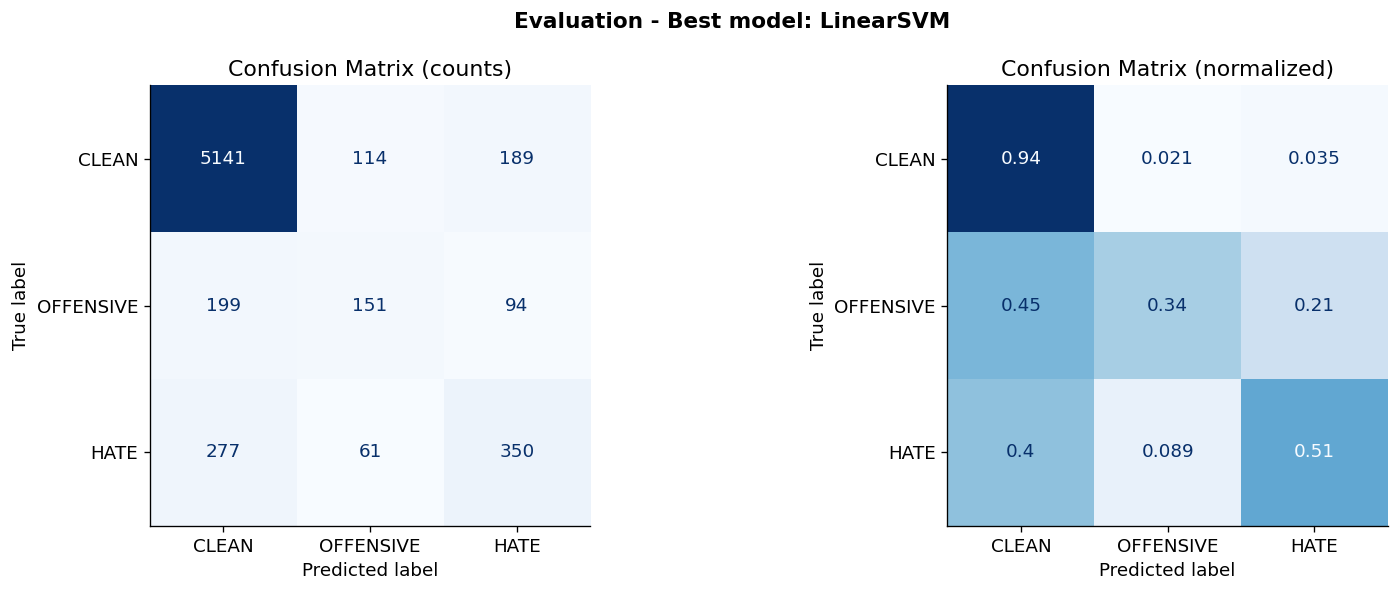


Best model: LinearSVM
Macro F1 = 0.6172
Accuracy = 0.8580
              precision    recall  f1-score   support

       CLEAN       0.92      0.94      0.93      5444
   OFFENSIVE       0.46      0.34      0.39       444
        HATE       0.55      0.51      0.53       688

    accuracy                           0.86      6576
   macro avg       0.64      0.60      0.62      6576
weighted avg       0.85      0.86      0.85      6576



In [57]:
best_model_name = results_df.iloc[0]['Model']
best_y_pred     = eval_results[best_model_name]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluation - Best model: {best_model_name}', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, best_y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABEL_NAMES).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (normalized)')

plt.tight_layout()
plt.savefig('7_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\nBest model: {best_model_name}")
print(f"Macro F1 = {eval_results[best_model_name]['macro_f1']:.4f}")
print(f"Accuracy = {eval_results[best_model_name]['accuracy']:.4f}")
print(classification_report(y_test, best_y_pred, target_names=LABEL_NAMES, zero_division=0))

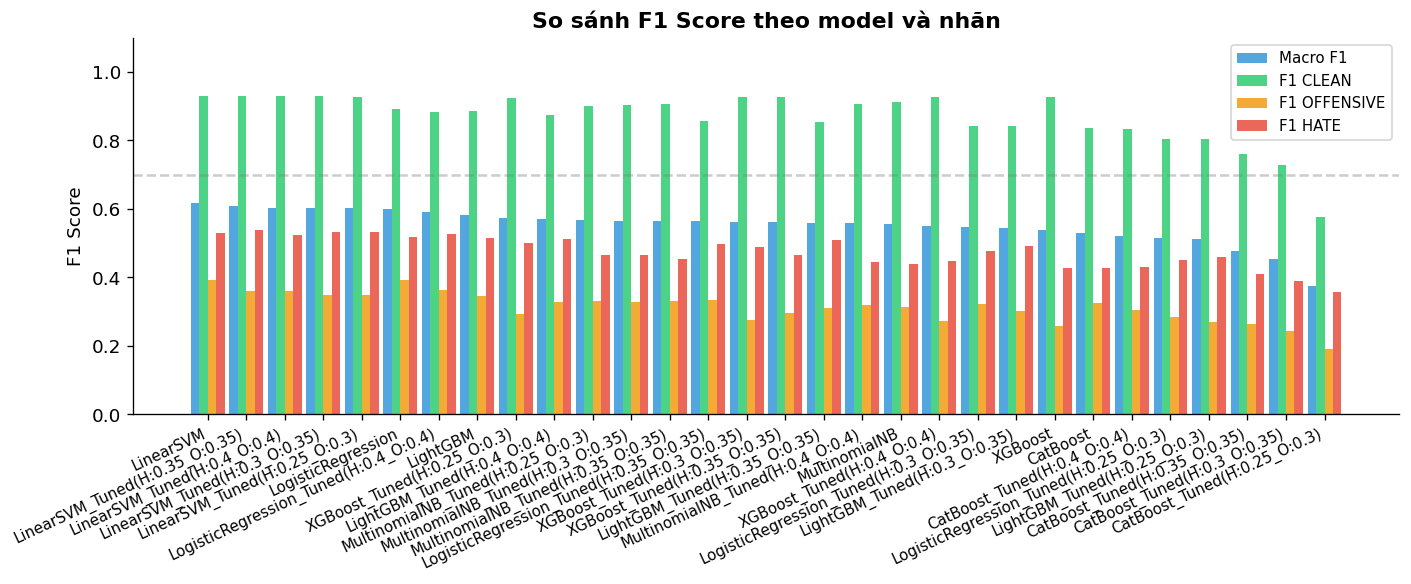

In [52]:
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(results_df))
width = 0.22
ax.bar(x - width*1.5, results_df['Macro F1'],    width, label='Macro F1',    color='#3498db', alpha=0.85)
ax.bar(x - width*0.5, results_df['F1 CLEAN'],    width, label='F1 CLEAN',    color='#2ecc71', alpha=0.85)
ax.bar(x + width*0.5, results_df['F1 OFFENSIVE'],width, label='F1 OFFENSIVE',color='#f39c12', alpha=0.85)
ax.bar(x + width*1.5, results_df['F1 HATE'],     width, label='F1 HATE',     color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.1)
ax.set_title('So sánh F1 Score theo model và nhãn', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('7_model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

Vẽ learning curve cho mô hình gốc: LinearSVM...


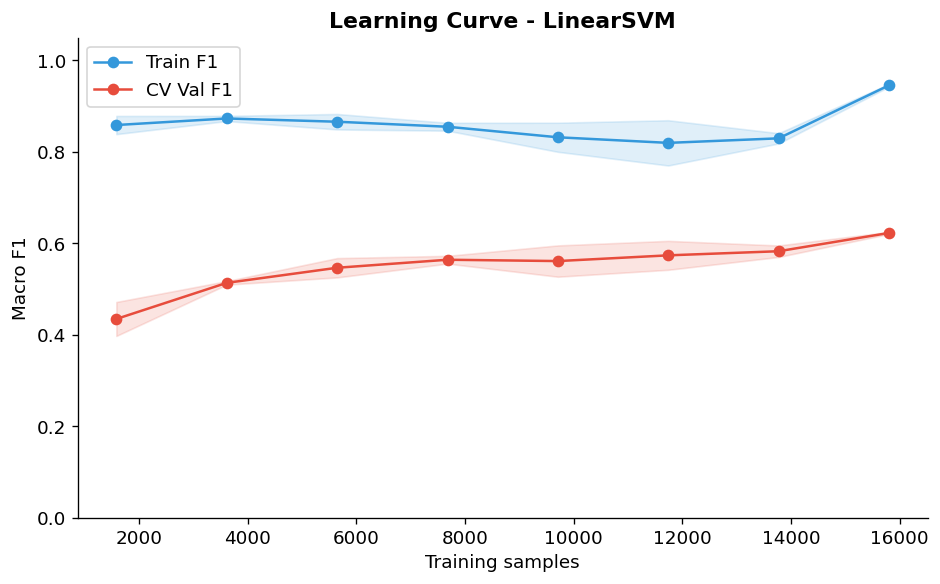

In [58]:
# Tách lấy tên gốc của mô hình (Nếu là LinearSVM_Tuned... thì chỉ lấy chữ LinearSVM)
base_model_name = best_model_name.split('_Tuned')[0]
print(f"Vẽ learning curve cho mô hình gốc: {base_model_name}...")

train_sizes, train_scores, val_scores = learning_curve(
    trained_models[base_model_name], X_train_sel, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='f1_macro', n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#3498db', label='Train F1')
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#e74c3c', label='CV Val F1')
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#e74c3c')
ax.set_xlabel('Training samples'); ax.set_ylabel('Macro F1')
ax.set_title(f'Learning Curve - {base_model_name}', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('7_learning_curve.png', bbox_inches='tight', dpi=120)
plt.show()


##Error Analysis & Interpretability

In [59]:
df_test_copy = df_test.copy()
df_test_copy['pred']      = best_y_pred
df_test_copy['pred_name'] = df_test_copy['pred'].map(LABEL_MAP)
df_test_copy['is_wrong']  = df_test_copy['label'] != df_test_copy['pred']

wrong_df = df_test_copy[df_test_copy['is_wrong']].copy()
print(f"Tổng số lỗi: {len(wrong_df)} / {len(df_test_copy)} ({len(wrong_df)/len(df_test_copy)*100:.1f}%)")
print("\nMa trận lỗi (True -> Predicted):")
print(pd.crosstab(wrong_df['label_name'], wrong_df['pred_name'], rownames=['True'], colnames=['Predicted']))
print()
hate_to_clean = ((df_test_copy['label_name']=='HATE') & (df_test_copy['pred_name']=='CLEAN')).sum()
off_to_clean  = ((df_test_copy['label_name']=='OFFENSIVE') & (df_test_copy['pred_name']=='CLEAN')).sum()
print(f"Các dạng lỗi nguy hiểm:")
print(f"   HATE -> CLEAN     : {hate_to_clean} cases (bỏ sót ngôn từ thù ghét)")
print(f"   OFFENSIVE -> CLEAN: {off_to_clean} cases")

Tổng số lỗi: 934 / 6576 (14.2%)

Ma trận lỗi (True -> Predicted):
Predicted  CLEAN  HATE  OFFENSIVE
True                             
CLEAN          0   189        114
HATE         277     0         61
OFFENSIVE    199    94          0

Các dạng lỗi nguy hiểm:
   HATE -> CLEAN     : 277 cases (bỏ sót ngôn từ thù ghét)
   OFFENSIVE -> CLEAN: 199 cases


In [60]:
print("\nCASE STUDY - 10 bình luận HATE bị predict thành CLEAN:\n")
cases = df_test_copy[
    (df_test_copy['label_name']=='HATE') & (df_test_copy['pred_name']=='CLEAN')
][['text', 'text_clean', 'label_name', 'pred_name']].head(10)

for i, (_, row) in enumerate(cases.iterrows(), 1):
    print(f"  [{i}] True: {row['label_name']} | Pred: {row['pred_name']}")
    print(f"       Raw  : {str(row['text'])[:100]}")
    print(f"       Clean: {str(row['text_clean'])[:100]}")
    print()


CASE STUDY - 10 bình luận HATE bị predict thành CLEAN:

  [1] True: HATE | Pred: CLEAN
       Raw  : Đề nghị 17, 22,23,32 đến phà vài hơi vào mẹt tk này để nó đi cách ly thế giới hẳn đi.
       Clean: đề_nghị 17 22 23 32 đến phà vài hơi vào mẹt tk này để nó đi cách_ly thế_giới hẳn đi

  [2] True: HATE | Pred: CLEAN
       Raw  : Trước sau j cũng đi theo phúc xạo lol
       Clean: trước sau đi phúc_xạo lon

  [3] True: HATE | Pred: CLEAN
       Raw  : Theo trung cộng đi rồi đến lúc ko còn lợi dụng đc bà sẽ thấy cảnh. Hãy nhớ câu đừng nghe những gì cs
       Clean: trung_cộng đi rồi đến lúc khong còn lợi_dụng bà sẽ thấy cảnh hãy nhớ câu đừng nghe những gì cs nói m

  [4] True: HATE | Pred: CLEAN
       Raw  : Con bé này nên xuống địa ngục quá tởm
       Clean: con_bé này nên xuống địa_ngục quá tởm

  [5] True: HATE | Pred: CLEAN
       Raw  : Đem ra bắn ngay cái thể loại ấy
       Clean: đem bắn ngay cái thể_loại ấy

  [6] True: HATE | Pred: CLEAN
       Raw  : Hải Yến bố cái con thái l

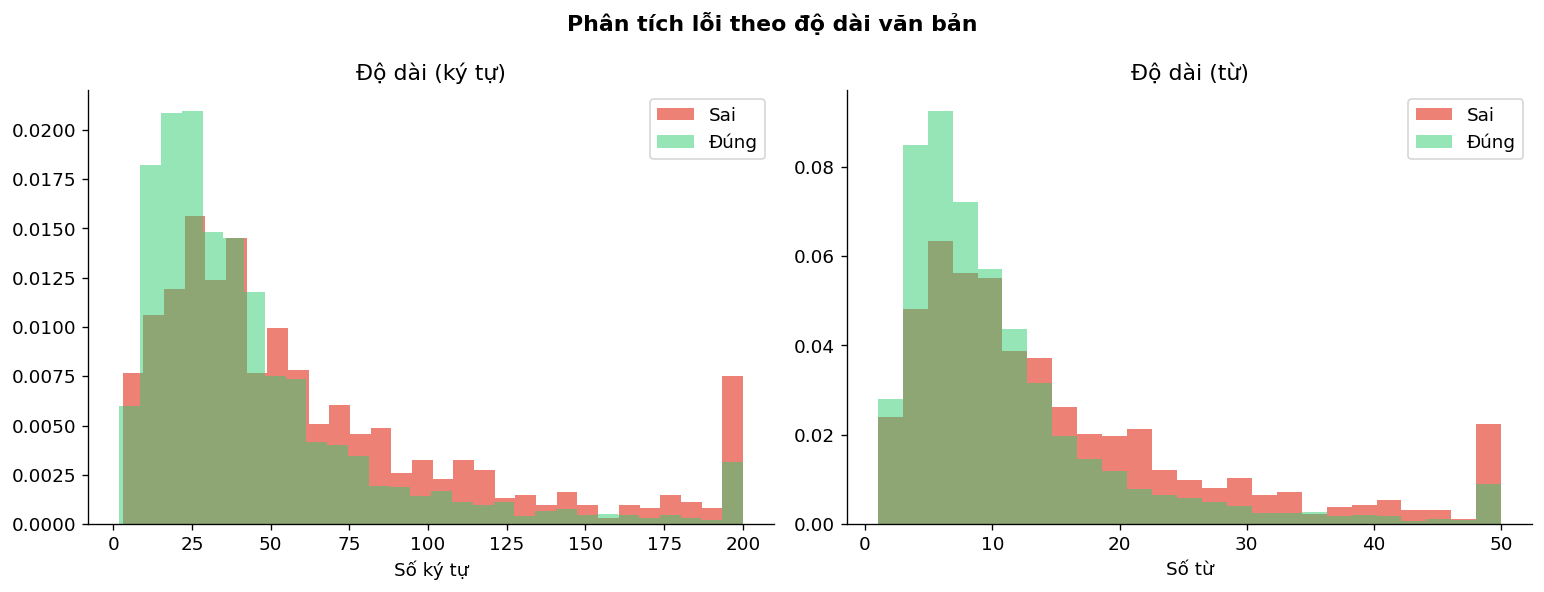

  Avg word count - Sai: 16.0 | Đúng: 10.9


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Phân tích lỗi theo độ dài văn bản', fontweight='bold')

ax = axes[0]
ax.hist(df_test_copy[df_test_copy['is_wrong']]['char_len'].clip(upper=200),
        bins=30, alpha=0.7, color='#e74c3c', label='Sai', density=True)
ax.hist(df_test_copy[~df_test_copy['is_wrong']]['char_len'].clip(upper=200),
        bins=30, alpha=0.5, color='#2ecc71', label='Đúng', density=True)
ax.set_title('Độ dài (ký tự)'); ax.set_xlabel('Số ký tự'); ax.legend()

ax = axes[1]
ax.hist(df_test_copy[df_test_copy['is_wrong']]['word_len'].clip(upper=50),
        bins=25, alpha=0.7, color='#e74c3c', label='Sai', density=True)
ax.hist(df_test_copy[~df_test_copy['is_wrong']]['word_len'].clip(upper=50),
        bins=25, alpha=0.5, color='#2ecc71', label='Đúng', density=True)
ax.set_title('Độ dài (từ)'); ax.set_xlabel('Số từ'); ax.legend()

plt.tight_layout()
plt.savefig('8_error_by_length.png', bbox_inches='tight', dpi=120)
plt.show()

avg_w = df_test_copy[df_test_copy['is_wrong']]['word_len'].mean()
avg_c = df_test_copy[~df_test_copy['is_wrong']]['word_len'].mean()
print(f"  Avg word count - Sai: {avg_w:.1f} | Đúng: {avg_c:.1f}")

In [62]:
from lime.lime_text import LimeTextExplainer

def predict_proba_fn(texts):
    cleaned  = [full_preprocess(t, use_tokenizer=USE_VN_TOKENIZER) for t in texts]
    X_tf_    = tfidf.transform(cleaned)
    X_ld_    = lda.transform(count_vec.transform(cleaned))
    X_lx_    = extract_lexicon_features(cleaned)
    X_st_    = np.zeros((len(cleaned), X_stat_train.shape[1]))
    X_feat_  = hstack([X_tf_, csr_matrix(X_ld_), csr_matrix(X_lx_), csr_matrix(X_st_)])
    X_sel_   = selector.transform(X_feat_)


    return trained_models['LogisticRegression'].predict_proba(X_sel_)

explainer = LimeTextExplainer(class_names=LABEL_NAMES, random_state=SEED)
sample_hate = df_test[df_test['label_name']=='HATE']['text'].iloc[0]
print(f"\nSample HATE: {sample_hate}")
try:
    exp = explainer.explain_instance(sample_hate, predict_proba_fn, num_features=10, num_samples=100, labels=[2])
    print("LIME Explanation - từ ảnh hưởng đến dự đoán HATE:")
    for feat, weight in exp.as_list(label=2):
        direction = "UP HATE" if weight > 0 else "DOWN HATE"
        print(f"  {direction:10s} | {weight:+.4f} | '{feat}'")
except Exception as e:
    print(f"LIME error: {e}")


Sample HATE: Thay Ngu
LIME Explanation - từ ảnh hưởng đến dự đoán HATE:
  UP HATE    | +0.0666 | 'Ngu'
  DOWN HATE  | -0.0314 | 'Thay'


In [63]:
print("\nABLATION STUDY - Bỏ từng nhóm feature, đo F1 thay đổi:")
baseline_model = trained_models['LogisticRegression']
y_pred_full    = baseline_model.predict(X_test_sel)
f1_full        = f1_score(y_test, y_pred_full, average='macro')
print(f"  {'Full features (baseline)':30s}: {f1_full:.4f}")

def ablate_and_score(X_tr, X_te, group_name):
    sel_abl = SelectKBest(chi2, k=min(15000, X_tr.shape[1]))
    Xtr_a = sel_abl.fit_transform(X_tr, y_train)
    Xte_a = sel_abl.transform(X_te)
    m = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                           class_weight='balanced', random_state=SEED, multi_class='multinomial')
    m.fit(Xtr_a, y_train)
    f1 = f1_score(y_test, m.predict(Xte_a), average='macro')
    print(f"  {group_name:30s}: {f1:.4f}  (delta = {f1-f1_full:+.4f})")

# SelectKBest từ sklearn.feature_selection
from sklearn.feature_selection import SelectKBest, chi2
ablate_and_score(X_tfidf_train, X_tfidf_test, "Chỉ TF-IDF")
ablate_and_score(hstack([X_tfidf_train, csr_matrix(X_lda_train)]), hstack([X_tfidf_test, csr_matrix(X_lda_test)]), "TF-IDF + LDA")
ablate_and_score(hstack([X_tfidf_train, csr_matrix(X_lex_train)]), hstack([X_tfidf_test, csr_matrix(X_lex_test)]), "TF-IDF + Lexicon")
print("-> Nhóm feature nào khi bỏ đi làm F1 giảm nhiều nhất tức là quan trọng nhất.")


ABLATION STUDY - Bỏ từng nhóm feature, đo F1 thay đổi:
  Full features (baseline)      : 0.6005
  Chỉ TF-IDF                    : 0.6048  (delta = +0.0043)
  TF-IDF + LDA                  : 0.6044  (delta = +0.0039)
  TF-IDF + Lexicon              : 0.6031  (delta = +0.0026)
-> Nhóm feature nào khi bỏ đi làm F1 giảm nhiều nhất tức là quan trọng nhất.


## Export Model & Ket qua

In [64]:
os.makedirs('outputs', exist_ok=True)

pipeline_obj = {
    'tfidf'          : tfidf,
    'count_vec'      : count_vec,
    'lda'            : lda,
    'selector'       : selector,
    'best_model'     : trained_models[best_model_name],
    'best_model_name': best_model_name,
    'label_map'      : LABEL_MAP,
    'label_names'    : LABEL_NAMES,
    'teen_code'      : TEEN_CODE_DICT,
    'stopwords'      : list(VN_STOPWORDS),
    'use_tokenizer'  : USE_VN_TOKENIZER
}

joblib.dump(pipeline_obj, 'outputs/vihsd_pipeline.pkl', compress=3)
results_df.to_csv('outputs/model_comparison.csv', index=False)
print("\nĐã lưu Pipeline: outputs/vihsd_pipeline.pkl")
print("Đã lưu Bảng kết quả: outputs/model_comparison.csv")


Đã lưu Pipeline: outputs/vihsd_pipeline.pkl
Đã lưu Bảng kết quả: outputs/model_comparison.csv


In [65]:
def predict_comment(text, pipeline):
    use_tok = pipeline.get('use_tokenizer', False)
    cleaned = full_preprocess(text, use_tokenizer=use_tok)

    if len(cleaned.strip()) == 0:
        cleaned = "empty"

    X_tf = pipeline['tfidf'].transform([cleaned])
    X_ld = pipeline['lda'].transform(pipeline['count_vec'].transform([cleaned]))
    X_lx = extract_lexicon_features([cleaned])

    temp_df = pd.DataFrame({'text': [text], 'text_clean': [cleaned]})
    X_st = extract_stat_features(temp_df)

    from scipy.sparse import hstack, csr_matrix
    X_f  = hstack([X_tf, csr_matrix(X_ld), csr_matrix(X_lx), csr_matrix(X_st)])
    X_s  = pipeline['selector'].transform(X_f)

    pred = pipeline['best_model'].predict(X_s)[0]
    return pipeline['label_map'][int(pred)], cleaned

loaded_pipeline = joblib.load('outputs/vihsd_pipeline.pkl')

test_comments = [
    "Bài hát hay quá, tôi thích lắm!",
    "Mày ngu vclllll, chỉ biết phá",
    "Lũ bán nước đáng bị xử bắn hết đi",
    "Chúc mừng sinh nhật bạn nhé!",
    "đmmmmmmm tml này làm cc gì vây???",
]

print("\nQuick Inference Test:")
for comment in test_comments:
    label, cleaned = predict_comment(comment, loaded_pipeline)
    icon = {'CLEAN':'OKE', 'OFFENSIVE':'WARN', 'HATE':'BLOCK'}.get(label, '❓')
    print(f"  {icon} [{label:10s}] {comment}")
    print(f"       -> Đã dọn dẹp thành: '{cleaned}'\n")


Quick Inference Test:
  OKE [CLEAN     ] Bài hát hay quá, tôi thích lắm!
       -> Đã dọn dẹp thành: 'bài hát quá tôi thích lắm'

  WARN [OFFENSIVE ] Mày ngu vclllll, chỉ biết phá
       -> Đã dọn dẹp thành: 'mày ngu vai ca_lon chỉ biết phá'

  BLOCK [HATE      ] Lũ bán nước đáng bị xử bắn hết đi
       -> Đã dọn dẹp thành: 'lũ bán nước đáng bị xử bắn hết đi'

  OKE [CLEAN     ] Chúc mừng sinh nhật bạn nhé!
       -> Đã dọn dẹp thành: 'chúc_mừng sinh_nhật bạn nhé'

  WARN [OFFENSIVE ] đmmmmmmm tml này làm cc gì vây???
       -> Đã dọn dẹp thành: 'đm to me_lon này làm gì vây'



In [66]:
print("\nTỔNG HỢP KẾT QUẢ CUỐI CÙNG:")
print(f"  Dataset     : ViHSD (uitnlp/vihsd) - {len(df_train)+len(df_val)+len(df_test):,} samples")
print(f"  Approach    : Pure ML - TF-IDF + Ensemble")
print(f"  Best model  : {best_model_name}")
print(f"  Macro F1    : {eval_results[best_model_name]['macro_f1']:.4f}")
print(f"  Accuracy    : {eval_results[best_model_name]['accuracy']:.4f}")
print("  Artifacts   : outputs/vihsd_pipeline.pkl, outputs/model_comparison.csv\n")


TỔNG HỢP KẾT QUẢ CUỐI CÙNG:
  Dataset     : ViHSD (uitnlp/vihsd) - 32,919 samples
  Approach    : Pure ML - TF-IDF + Ensemble
  Best model  : LinearSVM
  Macro F1    : 0.6172
  Accuracy    : 0.8580
  Artifacts   : outputs/vihsd_pipeline.pkl, outputs/model_comparison.csv



In [70]:
import numpy as np
# Bảng Đánh giá Tổng hợp Validation
comparison_data = []
print(f"Đang tổng hợp kết quả của {len(trained_models)} model trên tập Validation...")

for name, model in trained_models.items():
    y_pred_val = model.predict(X_val_sel)
    acc_val = accuracy_score(y_val, y_pred_val)
    f1_macro_val = f1_score(y_val, y_pred_val, average='macro')
    cv_info = cv_results.get(name, {})

    comparison_data.append({
        'Model': name,
        'Accuracy (Val)': acc_val,
        'Macro F1 (Val)': f1_macro_val,
        'CV F1 (Mean)': cv_info.get('mean', 'N/A'),
        'Train Time (s)': cv_info.get('time', 'N/A')
    })

df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.sort_values(by='Macro F1 (Val)', ascending=False).reset_index(drop=True)

print("BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP (VALIDATION):")

def format_numeric_or_string(value, format_spec):
    if isinstance(value, (int, float, np.number)):
        return format_spec.format(value)
    return str(value)

display(df_compare.style.format({
    'Accuracy (Val)': '{:.2%}',
    'Macro F1 (Val)': '{:.4f}',
    'CV F1 (Mean)': lambda x: format_numeric_or_string(x, '{:.4f}'),
    'Train Time (s)': lambda x: format_numeric_or_string(x, '{:.2f}')
}).highlight_max(subset=['Accuracy (Val)', 'Macro F1 (Val)'], color='lightgreen'))

df_compare.to_csv('outputs/validation_comparison.csv', index=False)
print("Đã lưu bảng Validation: outputs/validation_comparison.csv")

Đang tổng hợp kết quả của 30 model trên tập Validation...
BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP (VALIDATION):


,Model,Accuracy (Val),Macro F1 (Val),CV F1 (Mean),Train Time (s)
0,LinearSVM,84.73%,0.6050,0.6320,79.41
1,LogisticRegression,78.39%,0.5911,0.6120,543.95
2,LinearSVM_Tuned(H:0.35_O:0.35),84.96%,0.5898,N/A,N/A
3,LinearSVM_Tuned(H:0.3_O:0.35),84.88%,0.5883,N/A,N/A
4,LinearSVM_Tuned(H:0.25_O:0.3),84.69%,0.5877,N/A,N/A
5,LinearSVM_Tuned(H:0.4_O:0.4),85.00%,0.5849,N/A,N/A
6,LightGBM,78.35%,0.5830,0.5854,155.54
7,XGBoost_Tuned(H:0.25_O:0.3),85.07%,0.5754,N/A,N/A
8,LogisticRegression_Tuned(H:0.4_O:0.4),76.83%,0.5738,N/A,N/A
9,MultinomialNB_Tuned(H:0.3_O:0.35),81.47%,0.5735,N/A,N/A


Đã lưu bảng Validation: outputs/validation_comparison.csv


In [72]:
import joblib
import os

# 1. Lưu toàn bộ 6 models đã train ra một file pkl riêng biệt
joblib.dump(trained_models, 'outputs/all_trained_models.pkl', compress=3)
print("Đã lưu toàn bộ 6 models: outputs/all_trained_models.pkl")

# 2. Lệnh tự động tải file về máy (Chỉ hoạt động nếu bạn dùng Google Colab)
try:
    from google.colab import files
    print("\nĐang yêu cầu trình duyệt tải các file về máy cá nhân...")

    # Danh sách các file giá trị nhất của dự án cần tải về
    files_to_download = [
        'outputs/validation_comparison.csv', # Bảng kết quả Validation
        'outputs/model_comparison.csv',      # Bảng kết quả Test
        'outputs/vihsd_pipeline.pkl',        # Pipeline Model tốt nhất (dùng để làm Web/App)
        'outputs/all_trained_models.pkl'     # Toàn bộ 6 Models (dự phòng)
    ]

    for file_path in files_to_download:
        if os.path.exists(file_path):
            files.download(file_path)
        else:
            print(f"Cảnh báo: Không tìm thấy file {file_path}")

    print("Hoàn tất! Vui lòng kiểm tra thư mục 'Downloads' trên máy tính của bạn.")

except ImportError:
    # Nếu bạn chạy bằng Jupyter Notebook dưới máy local thì không cần tải, file đã nằm sẵn ở thư mục outputs
    print("\n(Bạn đang chạy trên Local, các file đã được lưu an toàn trong thư mục 'outputs')")

Đã lưu toàn bộ 6 models: outputs/all_trained_models.pkl

Đang yêu cầu trình duyệt tải các file về máy cá nhân...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Hoàn tất! Vui lòng kiểm tra thư mục 'Downloads' trên máy tính của bạn.


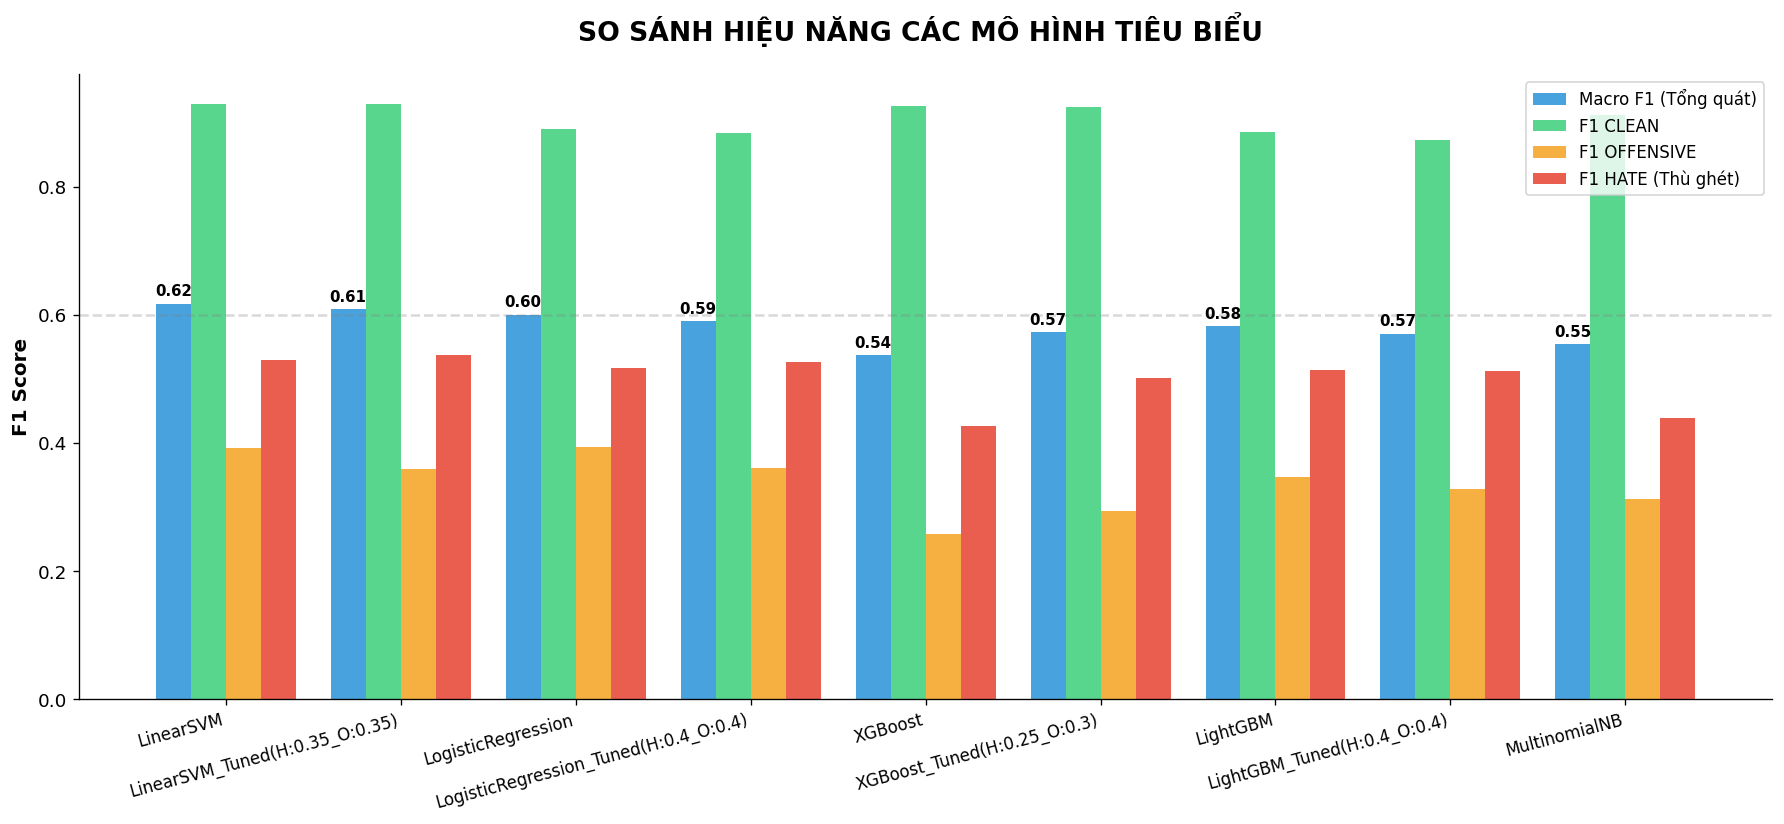

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Lọc danh sách các model tiêu biểu để vẽ (Tránh vẽ hết 30 cái gây rối)
# Chúng ta sẽ lấy mô hình gốc và mô hình Tuned xịn nhất của mỗi loại
selected_models = [
    'LinearSVM', 'LinearSVM_Tuned(H:0.35_O:0.35)',
    'LogisticRegression', 'LogisticRegression_Tuned(H:0.4_O:0.4)',
    'XGBoost', 'XGBoost_Tuned(H:0.25_O:0.3)',
    'LightGBM', 'LightGBM_Tuned(H:0.4_O:0.4)',
    'MultinomialNB'
]

# Lấy dữ liệu từ results_df chỉ cho các model đã chọn
plot_df = results_df[results_df['Model'].isin(selected_models)].copy()
# Đảm bảo thứ tự hiển thị đúng như danh sách chọn
plot_df['Model'] = pd.Categorical(plot_df['Model'], categories=selected_models, ordered=True)
plot_df = plot_df.sort_values('Model')

# 2. Thiết lập cấu trúc biểu đồ
fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(plot_df))
width = 0.2  # Độ rộng mỗi cột trong nhóm

# Vẽ từng nhóm cột
rects1 = ax.bar(x - width*1.5, plot_df['Macro F1'], width, label='Macro F1 (Tổng quát)', color='#3498db', alpha=0.9)
rects2 = ax.bar(x - width*0.5, plot_df['F1 CLEAN'], width, label='F1 CLEAN', color='#2ecc71', alpha=0.8)
rects3 = ax.bar(x + width*0.5, plot_df['F1 OFFENSIVE'], width, label='F1 OFFENSIVE', color='#f39c12', alpha=0.8)
rects4 = ax.bar(x + width*1.5, plot_df['F1 HATE'], width, label='F1 HATE (Thù ghét)', color='#e74c3c', alpha=0.9)

# 3. Trang trí biểu đồ cho chuyên nghiệp
ax.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax.set_title('SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH TIÊU BIỂU ', fontweight='bold', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=15, ha='right', fontsize=10)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=10)

# Thêm đường kẻ ngang ở mức 0.6 để làm mốc tham chiếu
ax.axhline(0.6, color='gray', linestyle='--', alpha=0.3)

# Thêm giá trị lên đầu các cột Macro F1 để dễ đọc
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)

plt.tight_layout()
plt.savefig('outputs/model_comparison_optimized.png', bbox_inches='tight', dpi=150)
plt.show()

In [78]:
import os
# Nén toàn bộ thư mục outputs thành file zip
!zip -r outputs.zip outputs

# Tải file zip về máy
from google.colab import files
files.download('outputs.zip')

updating: outputs/ (stored 0%)
updating: outputs/vihsd_pipeline.pkl (deflated 0%)
updating: outputs/all_trained_models.pkl (deflated 2%)
updating: outputs/model_comparison_optimized.png (deflated 18%)
updating: outputs/model_comparison.csv (deflated 56%)
updating: outputs/validation_comparison.csv (deflated 62%)
  adding: outputs/data/ (stored 0%)
  adding: outputs/data/raw_val.csv (deflated 58%)
  adding: outputs/data/processed_val.csv (deflated 61%)
  adding: outputs/data/processed_train.csv (deflated 62%)
  adding: outputs/data/processed_test.csv (deflated 62%)
  adding: outputs/data/raw_test.csv (deflated 58%)
  adding: outputs/data/raw_train.csv (deflated 59%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
import os
from google.colab import files

# 1. Nén thư mục catboost_info thành file zip
!zip -r catboost_info_logs.zip /content/catboost_info

# 2. Tải file zip đó về máy
files.download('catboost_info_logs.zip')

  adding: content/catboost_info/ (stored 0%)
  adding: content/catboost_info/tmp/ (stored 0%)
  adding: content/catboost_info/learn/ (stored 0%)
  adding: content/catboost_info/learn/events.out.tfevents (deflated 77%)
  adding: content/catboost_info/learn_error.tsv (deflated 53%)
  adding: content/catboost_info/time_left.tsv (deflated 49%)
  adding: content/catboost_info/catboost_training.json (deflated 74%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
import os
from google.colab import files

# Tạo thư mục data nếu chưa có
os.makedirs('outputs/data', exist_ok=True)

# 1. Lưu dữ liệu Raw (chỉ lấy cột text và label gốc)
df_train[['text', 'label']].to_csv('outputs/data/raw_train.csv', index=False)
df_val[['text', 'label']].to_csv('outputs/data/raw_val.csv', index=False)
df_test[['text', 'label']].to_csv('outputs/data/raw_test.csv', index=False)

# 2. Lưu dữ liệu Processed (bao gồm cột text_clean đã xử lý)
df_train[['text_clean', 'label']].to_csv('outputs/data/processed_train.csv', index=False)
df_val[['text_clean', 'label']].to_csv('outputs/data/processed_val.csv', index=False)
df_test[['text_clean', 'label']].to_csv('outputs/data/processed_test.csv', index=False)

print("Đã lưu các file CSV vào thư mục outputs/data/")

Đã lưu các file CSV vào thư mục outputs/data/
